# **Airline Passenger Demand Forecasting**


**Colab Link:** [Airline Passenger Demand Forecasting Notebook](https://colab.research.google.com/drive/1mOlALlm0IkNLVVM53aOwmUaqVGP-4W4c?usp=sharing)

## **Table of Contents**

1. [Problem Statement](#1-Problem-Statement)  
2. [Business Value](#2-Business-Value)  
3. [Data Source](#3-Data-Source)  
4. [Data Cleaning and Preparation](#4-Data-Cleaning-and-Preparation)  
5. [Exploratory Data Analysis](#5-Exploratory-Data-Analysis)  
6. [Null Model (Baseline Model)](#6-Null-Model)  
7. [Feature Engineering](#7-Feature-Engineering)  
8. [Modeling](#8-Modeling)  
9. [Evaluation](#9-Evaluation)  
10. [Conclusion](#10-Conclusion)  
11. [Challenges and Difficulties](#11-Challenges-and-Difficulties)
12. [AI Usage Disclosure](#12-AI-Usage-Disclosure)


## **1) Problem Statement**

This project aims to forecast total monthly passenger demand in the U.S. domestic airline market. Accurate demand prediction is critical for flight scheduling, capacity planning, pricing, and workforce allocation. Airlines, regulators, and airports rely on such forecasts to optimize operations and respond to market fluctuations. Our target variable, REV_PAX_MILES_140 (Revenue Passenger-Miles), measures the total miles flown by paying passengers, capturing both passenger volume and travel distance. Focusing on this metric provides a more comprehensive view of airline market activity and economic impact.



## **2) Business Value**
Forecasting Revenue Passenger-Miles (RPM) provides meaningful insight into both travel demand and the economic activity of the U.S. domestic airline market. Unlike simple passenger counts, RPM captures how far paying customers are traveling, making it a stronger indicator of market strength, route performance, and overall demand patterns.

Accurate RPM predictions help airlines make more informed decisions about capacity planning, fleet deployment, pricing strategies, and network adjustments. Airports and regulators can use these forecasts to evaluate infrastructure needs, anticipate congestion, and understand broader industry trends. By focusing on RPM, this analysis supports data-driven planning across the aviation ecosystem, improving operational efficiency and helping stakeholders respond effectively to changing travel patterns.


## **3) Data Source**
Our data comes from the U.S. Department of Transportation’s Bureau of Transportation Statistics (BTS), which publishes official public-use airline data. We’re using the T-100 Domestic Segment dataset, a monthly report that all certified U.S. airlines are required to submit. It includes key operational details like passengers carried, miles flown, and aircraft type. We combined files covering all of 2022, 2023, 2024 and the first half of 2025 to build our dataset, giving us a recent and reliable view of U.S. domestic airline activity.

Data Source Link: https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FJH&QO_fu146_anzr=Nv4-Db1b

## **4) Data Cleaning and Preparation**

### 4.1) Loading datasets

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!wget "https://raw.githubusercontent.com/kang25-gif/BA810/main/T_SCHEDULE_T1_2022.csv" -O T_SCHEDULE_T1_2022.csv
!wget "https://raw.githubusercontent.com/kang25-gif/BA810/main/T_SCHEDULE_T1_2023.csv" -O T_SCHEDULE_T1_2023.csv
!wget "https://raw.githubusercontent.com/kang25-gif/BA810/main/T_SCHEDULE_T1_2024.csv" -O T_SCHEDULE_T1_2024.csv
!wget "https://raw.githubusercontent.com/kang25-gif/BA810/main/T_SCHEDULE_T1_2025.csv" -O T_SCHEDULE_T1_2025.csv

--2025-12-08 06:10:30--  https://raw.githubusercontent.com/kang25-gif/BA810/main/T_SCHEDULE_T1_2022.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1694984 (1.6M) [text/plain]
Saving to: ‘T_SCHEDULE_T1_2022.csv’

T_SCHEDULE_T1_2022. 100%[===================>]   1.62M  --.-KB/s    in 0.06s   

2025-12-08 06:10:30 (25.1 MB/s) - ‘T_SCHEDULE_T1_2022.csv’ saved [1694984/1694984]

--2025-12-08 06:10:30--  https://raw.githubusercontent.com/kang25-gif/BA810/main/T_SCHEDULE_T1_2023.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16

In [3]:
schedule_22 = pd.read_csv('T_SCHEDULE_T1_2022.csv')
schedule_23 = pd.read_csv('T_SCHEDULE_T1_2023.csv')
schedule_24 = pd.read_csv('T_SCHEDULE_T1_2024.csv')
schedule_25 = pd.read_csv('T_SCHEDULE_T1_2025.csv')

files = [schedule_22, schedule_23, schedule_24, schedule_25]


In [4]:
# Show dtypes of each file
for i, df in enumerate(files, start=1):
    print(f"\nFile {i} dtypes:")
    print(df.dtypes)
    print("-"*80)



File 1 dtypes:
YEAR                               int64
QUARTER                            int64
MONTH                              int64
AIRLINE_ID                       float64
UNIQUE_CARRIER                    object
UNIQUE_CARRIER_NAME               object
UNIQUE_CARRIER_ENTITY             object
REGION                            object
CARRIER                           object
CARRIER_NAME                      object
CARRIER_GROUP                      int64
CARRIER_GROUP_NEW                float64
SERVICE_CLASS                     object
REV_PAX_ENP_110                  float64
REV_PAX_MILES_140                float64
REV_PAX_MILES_COACH              float64
REV_PAX_MILES_FIRST              float64
NON_REV_PAX_MILES                float64
REV_TON_MILES_240                float64
REV_TON_MILES_FREIGHT_247        float64
REV_TON_MILES_PAX_241            float64
REV_TON_MILES_USPR_MAIL          float64
REV_TON_MILES_USNONPR_MAIL       float64
REV_TON_MILES_MAIL_249           float64


After loading, confirming the correct row counts and basic structure ensures the datasets were imported successfully.

In [5]:
cols_to_fix = ["AIRLINE_ID", "CARRIER_GROUP_NEW"]

for df in [schedule_22, schedule_23, schedule_24, schedule_25]:
    df[cols_to_fix] = df[cols_to_fix].apply(pd.to_numeric, errors='coerce')
    df[cols_to_fix] = df[cols_to_fix].astype("Int64")   # nullable integer


### 4.2) Concatenating Datasets

In [6]:
schedule_all = pd.concat([schedule_22, schedule_23, schedule_24, schedule_25],
                         ignore_index=True)
schedule_all.shape

(26306, 37)

We loaded four yearly U.S. DOT T-100 airline schedule files (2022–2025) from Google Drive and verified that all datasets shared a consistent 37-column structure. Minor dtype inconsistencies—particularly in AIRLINE_ID and CARRIER_GROUP_NEW—were standardized using pandas’ nullable integer type to ensure clean concatenation. After aligning schemas, we combined all files into a single dataset of 26,306 records, which serves as the foundation for subsequent cleaning, EDA, and modeling.

### 4.3) Data Dictionary — Original Dataset Columns

---



Below is the complete data dictionary for the raw BTS T-100 Domestic Segment dataset before cleaning or feature removal.

| Column Name | Description | Data Type |
|------------|-------------|-----------|
| YEAR | Calendar year of the flight segment | int64 |
| QUARTER | Quarter of year (1–4) | int64 |
| MONTH | Month of year (1–12) | int64 |
| AIRLINE_ID | DOT-assigned unique numeric identifier for an airline certificate | int64 |
| UNIQUE_CARRIER | Unique marketing carrier code (e.g., AA, DL, WN) | object |
| UNIQUE_CARRIER_NAME | Full name of the Unique Carrier | object |
| UNIQUE_CARRIER_ENTITY | Unique entity code for carrier/region operations | object |
| REGION | Operation region (D = Domestic, A = Atlantic, P = Pacific, L = Latin America, I = International) | object |
| CARRIER | IATA code of the reporting/operating carrier | object |
| CARRIER_NAME | Full operating carrier name | object |
| CARRIER_GROUP | Carrier group category (Legacy system) | int64 |
| CARRIER_GROUP_NEW | New carrier group classification (0–9 categories) | int64 |
| SERVICE_CLASS | Type of service (F, K, L, V, Z, P, G) | object |
| REV_PAX_ENP_110 | Revenue passengers enplaned (boarded) | float64 |
| REV_PAX_MILES_140 | Revenue passenger-miles (target variable) | float64 |
| REV_PAX_MILES_COACH | Passenger miles flown in coach class | float64 |
| REV_PAX_MILES_FIRST | Passenger miles flown in first class | float64 |
| NON_REV_PAX_MILES | Non-revenue passenger miles | float64 |
| REV_TON_MILES_240 | Total revenue ton-miles | float64 |
| REV_TON_MILES_FREIGHT_247 | Revenue ton-miles for freight | float64 |
| REV_TON_MILES_PAX_241 | Revenue ton-miles attributable to passengers | float64 |
| REV_TON_MILES_USPR_MAIL | U.S. Priority Mail ton-miles | float64 |
| REV_TON_MILES_USNONPR_MAIL | U.S. Non-Priority Mail ton-miles | float64 |
| REV_TON_MILES_MAIL_249 | Total revenue mail ton-miles | float64 |
| REV_TON_MILES_FOREIGN_MAIL | Foreign mail ton-miles | float64 |
| REV_TON_MILES_EXPRESS_MAIL | Express mail ton-miles | float64 |
| NON_REV_TON_MILES | Non-revenue ton-miles | float64 |
| AVL_TON_MILES_280 | Available ton-miles (total weight capacity × distance) | float64 |
| AVL_SEAT_MILES_320 | Available seat-miles (ASM: seats × distance) | float64 |
| AVL_SEAT_MILES_FIRST | Available first-class seat-miles | float64 |
| AVL_SEAT_MILES_COACH | Available coach seat-miles | float64 |
| REV_ACRFT_MILES_FLOWN_410 | Actual revenue aircraft miles flown | float64 |
| REV_ACRFT_MILES_SCH_430 | Revenue aircraft miles scheduled (planned) | float64 |
| REV_ACRFT_MILES_SCH_COMPLETED | Scheduled revenue miles actually completed | float64 |
| REV_ACRFT_DEP_PERF_510 | Revenue aircraft departures performed | float64 |
| REV_ACRFT_HRS_AIRBORNE_610 | Aircraft airborne hours (wheels up → wheels down) | float64 |
| ACRFT_HRS_RAMPTORAMP_630 | Total aircraft block hours (gate departure → gate arrival) | float64 |



In [7]:
schedule_all.head(3)

,YEAR,QUARTER,MONTH,AIRLINE_ID,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME,UNIQUE_CARRIER_ENTITY,REGION,CARRIER,CARRIER_NAME,...,AVL_TON_MILES_280,AVL_SEAT_MILES_320,AVL_SEAT_MILES_FIRST,AVL_SEAT_MILES_COACH,REV_ACRFT_MILES_FLOWN_410,REV_ACRFT_MILES_SCH_430,REV_ACRFT_MILES_SCH_COMPLETED,REV_ACRFT_DEP_PERF_510,REV_ACRFT_HRS_AIRBORNE_610,ACRFT_HRS_RAMPTORAMP_630
0,2022,1,1,19393,WN,Southwest Airlines Co.,06725,D,WN,Southwest Airlines Co.,...,1.334280e+09,1.089834e+10,1.089834e+10,0.0,69520522.0,74282384.0,NaN,91102.0,160370.0,188789.0
1,2022,1,1,19393,WN,Southwest Airlines Co.,06725,D,WN,Southwest Airlines Co.,...,1.334280e+09,1.089834e+10,1.089834e+10,0.0,69520522.0,74282384.0,NaN,91102.0,160370.0,188789.0
2,2022,1,1,19393,WN,Southwest Airlines Co.,06725,D,WN,Southwest Airlines Co.,...,1.094040e+05,8.968320e+05,8.968320e+05,0.0,5888.0,0.0,NaN,8.0,13.0,15.0


In [8]:
schedule_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26306 entries, 0 to 26305
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   YEAR                           26306 non-null  int64  
 1   QUARTER                        26306 non-null  int64  
 2   MONTH                          26306 non-null  int64  
 3   AIRLINE_ID                     26288 non-null  Int64  
 4   UNIQUE_CARRIER                 26288 non-null  object 
 5   UNIQUE_CARRIER_NAME            26288 non-null  object 
 6   UNIQUE_CARRIER_ENTITY          26288 non-null  object 
 7   REGION                         26288 non-null  object 
 8   CARRIER                        26306 non-null  object 
 9   CARRIER_NAME                   26288 non-null  object 
 10  CARRIER_GROUP                  26306 non-null  int64  
 11  CARRIER_GROUP_NEW              26288 non-null  Int64  
 12  SERVICE_CLASS                  26306 non-null 

In [9]:
(schedule_all['UNIQUE_CARRIER'] == schedule_all['CARRIER']).all()


np.False_

In [10]:
schedule_all[schedule_all['UNIQUE_CARRIER'] != schedule_all['CARRIER']].head(10)


,YEAR,QUARTER,MONTH,AIRLINE_ID,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME,UNIQUE_CARRIER_ENTITY,REGION,CARRIER,CARRIER_NAME,...,AVL_TON_MILES_280,AVL_SEAT_MILES_320,AVL_SEAT_MILES_FIRST,AVL_SEAT_MILES_COACH,REV_ACRFT_MILES_FLOWN_410,REV_ACRFT_MILES_SCH_430,REV_ACRFT_MILES_SCH_COMPLETED,REV_ACRFT_DEP_PERF_510,REV_ACRFT_HRS_AIRBORNE_610,ACRFT_HRS_RAMPTORAMP_630
215,2022,1,1,20272,M5,Kenmore Air Harbor,06927,D,KAH,Kenmore Air Harbor,...,18083.0,135414.0,135414.0,0.0,15393.0,15393.0,NaN,307.0,149.0,175.0
216,2022,1,1,20272,M5,Kenmore Air Harbor,06927,D,KAH,Kenmore Air Harbor,...,18083.0,135414.0,135414.0,0.0,15393.0,15393.0,NaN,307.0,149.0,175.0
217,2022,1,1,20272,M5,Kenmore Air Harbor,06927,D,KAH,Kenmore Air Harbor,...,3506.0,32844.0,32844.0,0.0,4422.0,0.0,NaN,28.0,24.0,27.0
218,2022,1,1,20272,M5,Kenmore Air Harbor,06927,D,KAH,Kenmore Air Harbor,...,3506.0,32844.0,32844.0,0.0,4422.0,0.0,NaN,28.0,24.0,27.0
219,2022,1,1,20272,M5,Kenmore Air Harbor,06927,D,KAH,Kenmore Air Harbor,...,21589.0,168258.0,168258.0,0.0,19815.0,15393.0,NaN,335.0,173.0,202.0
399,2022,1,1,20426,VD,Vieques Air Link Inc.,07023,D,VI,Vieques Air Link Inc.,...,43327.0,461790.0,461790.0,0.0,33795.0,54485.0,NaN,1214.0,279.0,349.0
400,2022,1,1,20426,VD,Vieques Air Link Inc.,07023,D,VI,Vieques Air Link Inc.,...,43327.0,461790.0,461790.0,0.0,33795.0,54485.0,NaN,1214.0,279.0,349.0
401,2022,1,1,20426,VD,Vieques Air Link Inc.,07023,D,VI,Vieques Air Link Inc.,...,43327.0,461790.0,461790.0,0.0,33795.0,54485.0,NaN,1214.0,279.0,349.0
455,2022,1,1,21080,TJ,Tradewind Aviation,01126,D,04Q,Tradewind Aviation,...,224862.0,1042840.0,1042840.0,0.0,130355.0,130355.0,NaN,679.0,545.0,655.0
456,2022,1,1,21080,TJ,Tradewind Aviation,01126,D,04Q,Tradewind Aviation,...,224862.0,1042840.0,1042840.0,0.0,130355.0,130355.0,NaN,679.0,545.0,655.0


In the dataset, the `UNIQUE_CARRIER` and `CARRIER` fields represent two different roles in airline operations:

- **UNIQUE_CARRIER (Marketing Carrier):**  
  This is the airline that sells the ticket and markets the flight to customers.  
  Example: American Airlines may appear as the marketing carrier on a ticket.

- **CARRIER (Operating Carrier):**  
  This is the airline that physically operates the flight (provides the aircraft, crew, and equipment).  
  Example: A flight marketed by American may actually be flown by SkyWest.

In [11]:
corr = schedule_all.corr(numeric_only=True)['REV_PAX_MILES_140'].sort_values(ascending=False)
corr


,REV_PAX_MILES_140
REV_TON_MILES_PAX_241,1.000000
REV_PAX_MILES_FIRST,1.000000
REV_PAX_MILES_140,1.000000
AVL_SEAT_MILES_320,0.998308
AVL_SEAT_MILES_FIRST,0.998308
REV_ACRFT_MILES_SCH_430,0.974286
REV_ACRFT_MILES_FLOWN_410,0.973216
REV_ACRFT_HRS_AIRBORNE_610,0.961620
ACRFT_HRS_RAMPTORAMP_630,0.952021
REV_PAX_ENP_110,0.951301


### 4.4) Dropping Irrelevant Columns

In [12]:
cols_to_drop = [

    # Empty / irrelevant
    "NON_REV_PAX_MILES",
    "REV_TON_MILES_USPR_MAIL",
    "REV_TON_MILES_USNONPR_MAIL",
    "REV_TON_MILES_FOREIGN_MAIL",
    "REV_TON_MILES_EXPRESS_MAIL",
    "NON_REV_TON_MILES",
    "REV_ACRFT_MILES_SCH_COMPLETED",
    "AVL_SEAT_MILES_COACH",

    # Leakage — components of the target
    "REV_PAX_MILES_COACH",
    "REV_PAX_MILES_FIRST",
    "REV_TON_MILES_PAX_241",
    "AVL_SEAT_MILES_FIRST",

    # Leakage — **post-flight outcomes**
    "REV_ACRFT_MILES_FLOWN_410",
    "REV_ACRFT_HRS_AIRBORNE_610",
    "ACRFT_HRS_RAMPTORAMP_630",
    "REV_ACRFT_DEP_PERF_510",
    "REV_PAX_ENP_110",

    # Cargo/mail
    "REV_TON_MILES_240",
    "REV_TON_MILES_MAIL_249",
    "REV_TON_MILES_FREIGHT_247",

    # Redundant / branding labels
    "AIRLINE_ID",
    "UNIQUE_CARRIER_NAME",
    "CARRIER_NAME",
    "CARRIER_GROUP",
    "UNIQUE_CARRIER_ENTITY",
]

# Drop the columns
schedule_all = schedule_all.drop(columns=cols_to_drop)

- Dropped columns with 0 non-null values because they contain no usable information and only add noise.

- Removed leakage columns (coach, first-class, and passenger ton-miles) because they directly encode parts of the target variable and would cause the model to cheat.

- Eliminated cargo-related variables (freight and mail ton miles) since they describe cargo operations, not passenger demand, and show almost no correlation with the target.

- Removed redundant columns such as CARRIER_NAME and CARRIER_GROUP because cleaner, more useful versions of these attributes already exist (UNIQUE_CARRIER, CARRIER_GROUP_NEW).

- Dropped UNIQUE_CARRIER_ENTITY because it is an internal certificate ID that provides no meaningful signal for predicting passenger demand.

In [13]:
# Renaming only the columns that still exist after leakage removal
schedule_all = schedule_all.rename(columns={

    # Time identifiers
    "YEAR": "year",
    "QUARTER": "quarter",
    "MONTH": "month",

    # Airline identifiers
    "UNIQUE_CARRIER": "marketing_carrier",
    "REGION": "region",
    "CARRIER": "operating_carrier",
    "CARRIER_GROUP_NEW": "carrier_group",
    "SERVICE_CLASS": "service_class",

    # Passenger demand (target + main predictor)
    "REV_PAX_MILES_140": "revenue_passenger_miles",
    "REV_ACRFT_MILES_SCH_430": "scheduled_miles",

    # Capacity variables (SAFE)
    "AVL_TON_MILES_280": "available_ton_miles",
    "AVL_SEAT_MILES_320": "available_seat_miles",
})


In [14]:
schedule_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26306 entries, 0 to 26305
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     26306 non-null  int64  
 1   quarter                  26306 non-null  int64  
 2   month                    26306 non-null  int64  
 3   marketing_carrier        26288 non-null  object 
 4   region                   26288 non-null  object 
 5   operating_carrier        26306 non-null  object 
 6   carrier_group            26288 non-null  Int64  
 7   service_class            26306 non-null  object 
 8   revenue_passenger_miles  26289 non-null  float64
 9   available_ton_miles      26289 non-null  float64
 10  available_seat_miles     26289 non-null  float64
 11  scheduled_miles          26289 non-null  float64
dtypes: Int64(1), float64(4), int64(3), object(4)
memory usage: 2.4+ MB


### 4.5) Handling Missing Values and Standardizing Column Types


In [15]:
schedule_all = schedule_all.dropna()

We dropped the rows that had null value because it was only 0.36% which wouldnt cause a sinificant difference

In [16]:
schedule_all.isnull().sum()

,0
year,0
quarter,0
month,0
marketing_carrier,0
region,0
operating_carrier,0
carrier_group,0
service_class,0
revenue_passenger_miles,0
available_ton_miles,0


In [17]:
categorical_cols = [
    "year", "quarter", "month",
    "marketing_carrier",
    "region", "operating_carrier",
    "carrier_group", "service_class"
]

schedule_all[categorical_cols] = schedule_all[categorical_cols].astype("category")
schedule_all.dtypes

,0
year,category
quarter,category
month,category
marketing_carrier,category
region,category
operating_carrier,category
carrier_group,category
service_class,category
revenue_passenger_miles,float64
available_ton_miles,float64


In [18]:
schedule_all.duplicated().sum()


np.int64(0)

**Data Cleaning Summary**

We removed columns with no usable values, variables that would leak information about the target, and cargo-related fields that are unrelated to passenger demand. Redundant identifiers were also dropped to reduce noise and multicollinearity. Finally, we standardized column names, leaving a clean set of meaningful features for analysis and modeling.

## **5) Exploratory Data Analysis**

### 5.1) Summary Statistics

In [19]:
schedule_all.describe()

,revenue_passenger_miles,available_ton_miles,available_seat_miles,scheduled_miles
count,2.627100e+04,2.627100e+04,2.627100e+04,2.627100e+04
mean,4.497428e+08,1.098547e+08,5.433962e+08,3.481380e+06
std,1.692875e+09,3.000408e+08,2.013081e+09,1.185169e+07
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,6.110250e+04,6.030000e+03,0.000000e+00
50%,2.188200e+05,1.332223e+06,5.840810e+05,1.816000e+03
75%,1.320632e+07,3.900175e+07,2.826434e+07,7.581045e+05
max,1.348984e+10,2.198155e+09,1.612835e+10,9.995280e+07


**Key Insights:**

- The dataset spans **2022–2025**, with good coverage across quarters and months.
- Many observations show zero RPM and zero capacity, indicating months or segments with no activity.
- revenue_passenger_miles is highly skewed: the median is low, but a few very large values push the mean up.
- Capacity variables (available_ton_miles, available_seat_miles, scheduled_miles) show the same pattern—many small values and a few extremely large ones.
- The wide ranges suggest the dataset includes both small regional segments and large, long-haul operations.


### 5.2) Correlation Heatmap of Numerical Features

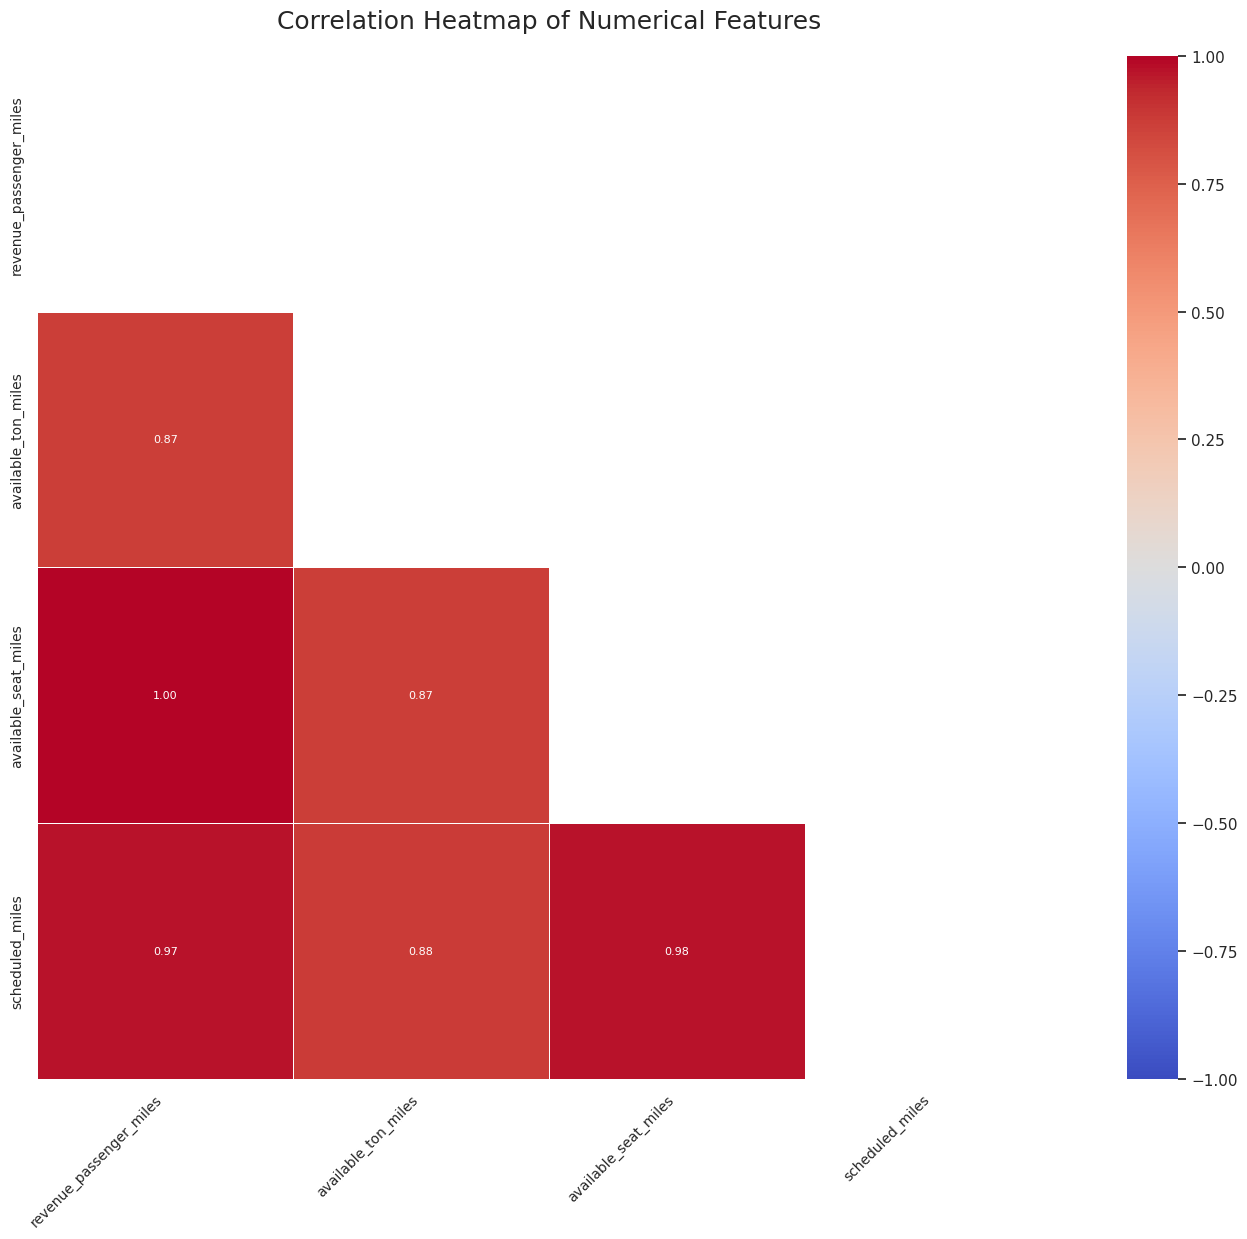

In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
num_cols = schedule_all.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation matrix
corr = schedule_all[num_cols].corr()

# Create a mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set style
sns.set_theme(style="white")

# Create figure
plt.figure(figsize=(14, 12))

# Draw heatmap
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    vmax=1,
    vmin=-1,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    square=True,
    linewidths=0.5,
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=18, pad=20)
plt.xticks(fontsize=10, rotation=45, ha="right")
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


**Key Insight:**

- All operational capacity variables — available seat miles, available ton miles, and scheduled miles — show very strong positive correlation with the target variable revenue passenger miles (R² ≈ 0.87–0.99).

**Interpretation:**

- This is expected because airlines generate demand (RPM) by offering seat capacity on scheduled routes.
Higher capacity → more passengers → more miles flown → higher RPM.

**Business Meaning:**

- Airlines control these capacity levers. Adjusting scheduled miles or seat capacity is the primary way they respond to expected demand.

**Modeling Implication:**

- These features are legitimate predictors, not leakage — they are known before the flight occurs.

### 5.3) Pairplot

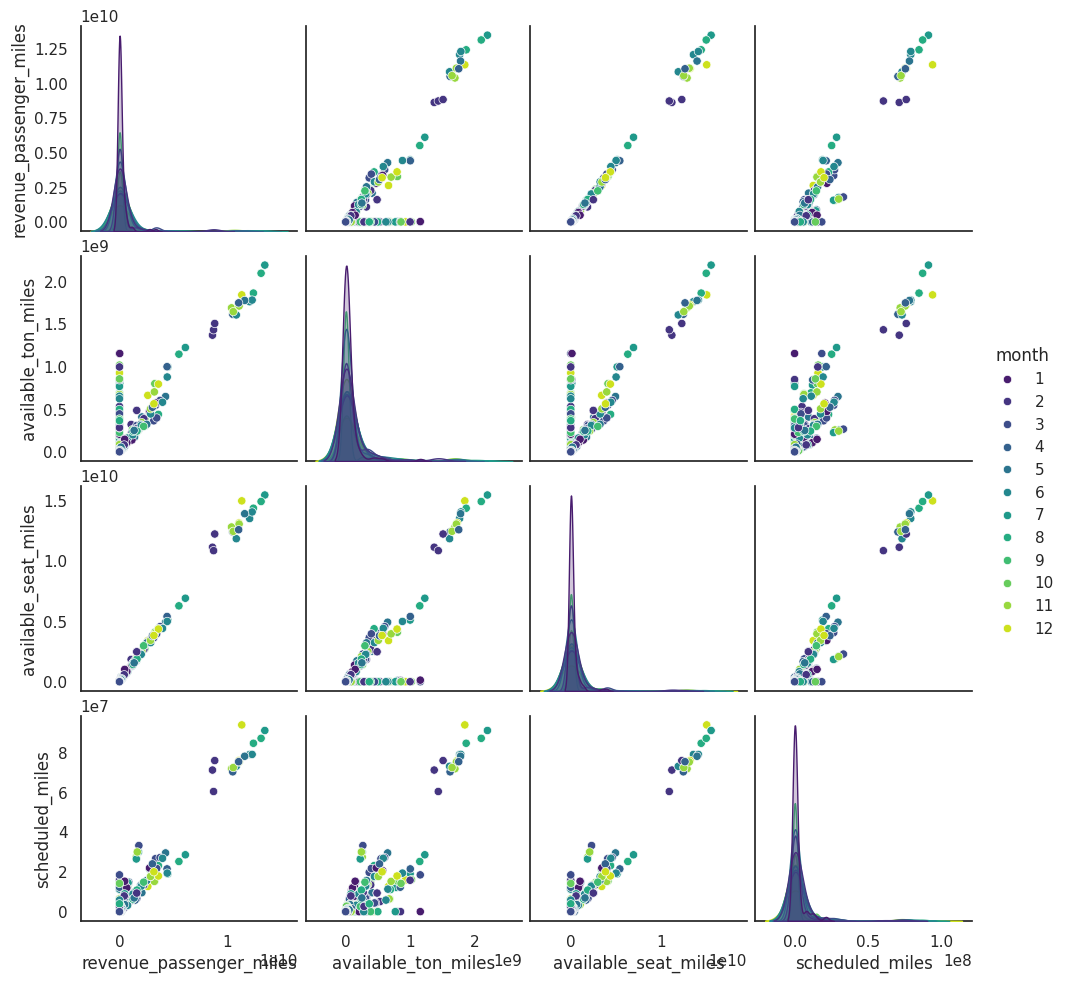

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample to keep the plot readable
schedule_sample = schedule_all.sample(1000, random_state=42)

# Choose key variable
useful_vars = [
    "revenue_passenger_miles",
    "available_ton_miles",
    "available_seat_miles",
    "scheduled_miles"
]

sns.pairplot(
    schedule_sample,
    vars=useful_vars,
    hue="month",
    palette="viridis",
    diag_kind="kde",
)
plt.show()


**Key Insight:**  
- Scatterplots show strong linear relationships across all numeric features, and KDE plots reveal clear right-skew, indicating that large carriers dominate the dataset.

**Interpretation:**  
- Airlines tend to scale operations proportionally (more aircraft miles → more seat miles → more passenger miles).  
- Smaller carriers cluster separately due to operating at much lower capacity levels.  
- The linear structure suggests that both linear models and tree-based models should perform well.

**Business Meaning:**  
- Market presence is closely tied to fleet size and scheduling frequency — carriers with larger networks naturally generate more passenger miles.

**Modeling Implication:**  
- Feature scaling may be important for certain algorithms, and the strong skew may benefit from log transformations to stabilize variance and improve model performance.


### 5.4) Seasonality Trends

**Passenger Miles by Month & Year**

/tmp/ipython-input-4226149712.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["year", "month"])["revenue_passenger_miles"]


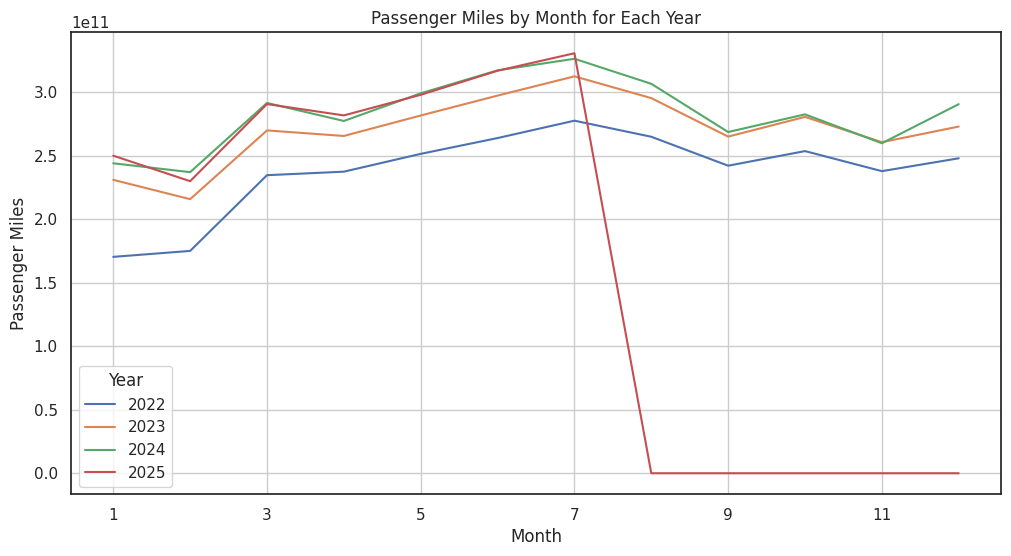

In [22]:
df = schedule_all.copy()

# Remove 2025 months after July (year & month are categorical → cast to int)
df = df[~((df["year"].astype(int) == 2025) & (df["month"].astype(int) > 7))]

# Recompute monthly sums
monthly = (
    df.groupby(["year", "month"])["revenue_passenger_miles"]
    .sum()
    .unstack(level=0)
)

# Plot again
monthly.plot(figsize=(12, 6))
plt.title("Passenger Miles by Month for Each Year")
plt.xlabel("Month")
plt.ylabel("Passenger Miles")
plt.grid(True)
plt.legend(title="Year")
plt.show()


**Key Insight:**  
- Across all years, RPM peaks between June–August, with noticeable drops in September and winter months.

**Interpretation:**  
- Strong seasonality in summer → peak travel season  
- Shoulder seasons (March–May, September–October) have stable but lower demand  
- Winter shows the lowest RPM except holidays  
- 2025 shows zeros beyond July because data is incomplete — not an actual collapse.

**Business Meaning:**  
- Airlines allocate more aircraft and increase flight frequencies in summer.  
Demand forecasting must capture seasonal cycles — month is a highly predictive feature.

**Modeling Implication:**  
- Include month, quarter, region, and carrier_group as categorical predictors to learn seasonal patterns.


**Average Passenger Miles by Month (Aggregated Seasonality)**

/tmp/ipython-input-17490565.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = schedule_all.groupby("month")["revenue_passenger_miles"].mean()


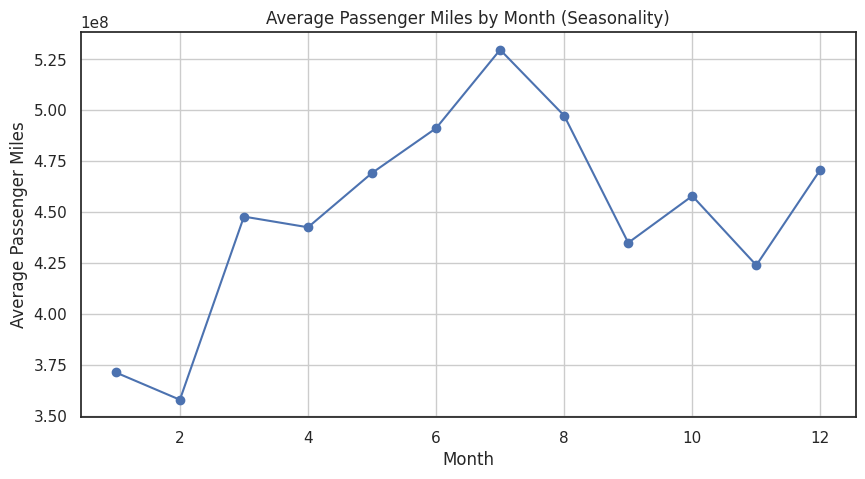

In [23]:
import matplotlib.pyplot as plt

monthly_avg = schedule_all.groupby("month")["revenue_passenger_miles"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Average Passenger Miles")
plt.title("Average Passenger Miles by Month (Seasonality)")
plt.grid(True)
plt.show()


**Key Insight:**  
- Mean RPM rises steadily through spring → peaks in July → falls afterward.

**Interpretation:**  
- This smooth seasonal curve confirms what the line plot suggests:  
summer is the dominant demand driver.

**Business Meaning:**  
- Airlines optimize pricing, staffing, fleet deployment, and marketing around these seasonal peaks.

**Modeling Implication:**  
- Explicitly engineer seasonality features if needed (e.g., sine/cosine month encoding).  
For now, month as a categorical variable is sufficient.


**Monthly Seasonality of Passenger Miles**

This plot shows clear seasonal patterns in passenger demand. Traffic is consistently lowest in January and February, then rises sharply in March and continues climbing into the summer. The peak occurs in July, which aligns with the busy travel season, before gradually declining through the fall. Overall, the trend reflects strong summer demand and weaker winter travel, which is typical for U.S. aviation markets.

### 5.5) Distribution of Passenger Miles

**Distribution of Passenger Miles by Month (Scatter Plot)**

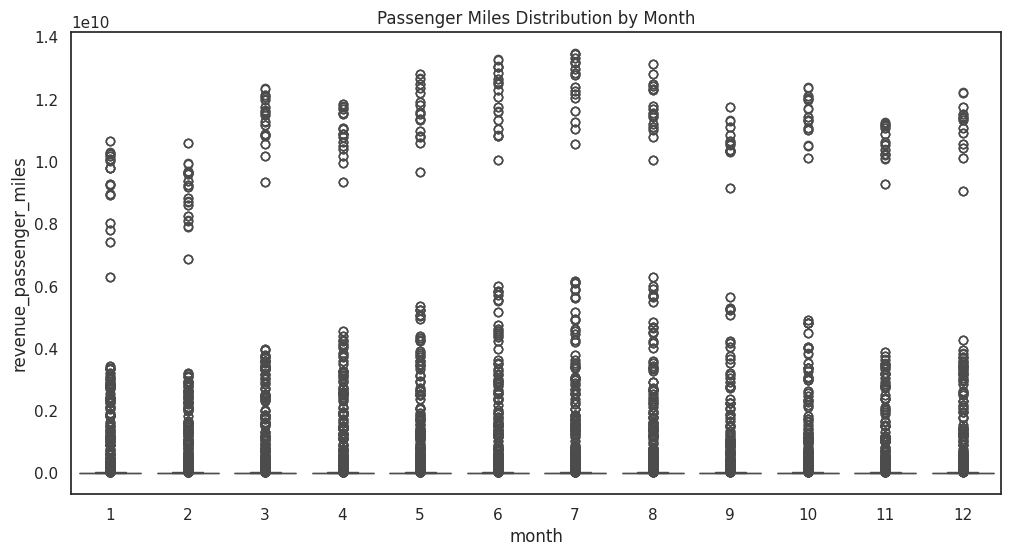

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=schedule_all, x="month", y="revenue_passenger_miles")
plt.title("Passenger Miles Distribution by Month")
plt.show()


**Key Insight:**  
- Within each month, RPM varies across airlines by more than an order of magnitude.

**Interpretation:**  
- Big carriers (WN, AA, DL, UA) generate extremely high RPM  
- Regionals show near-zero RPM  
- Monthly patterns appear as stacked vertical clusters

**Business Meaning:**  
- Demand varies dramatically by airline size — fleet scale and network strategy determine market reach.

**Modeling Implication:**  
- Categorical variables such as carrier, region, and carrier_group will significantly improve predictive power.


**Overall Distribution of Passenger Miles (Histogram)**

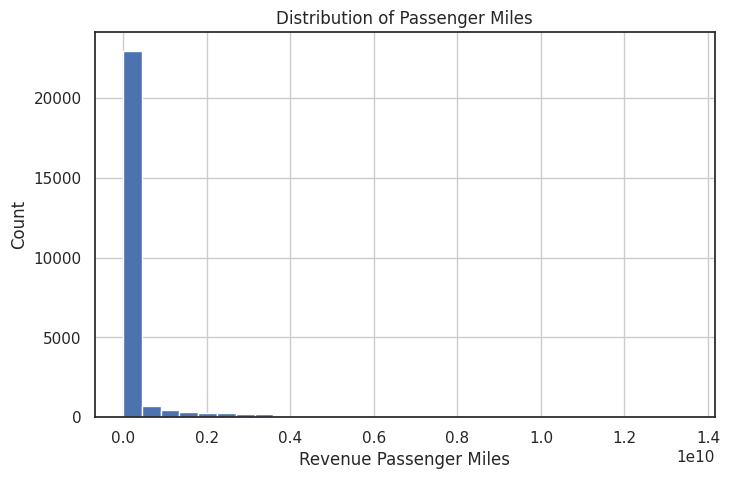

count    2.627100e+04
mean     4.497428e+08
std      1.692875e+09
min      0.000000e+00
25%      0.000000e+00
50%      2.188200e+05
75%      1.320632e+07
max      1.348984e+10
Name: revenue_passenger_miles, dtype: float64


In [25]:
plt.figure(figsize=(8,5))
schedule_all["revenue_passenger_miles"].hist(bins=30)
plt.title("Distribution of Passenger Miles")
plt.xlabel("Revenue Passenger Miles")
plt.ylabel("Count")
plt.grid(True)
plt.show()

print(schedule_all["revenue_passenger_miles"].describe())


**Key Insight:**  
- RPM is extremely right-skewed — small carriers dominate the dataset count, but large carriers dominate total demand.

**Interpretation:**  
- This is normal for airline data.  
A small number of carriers operate huge fleets.

**Business Meaning:**  
- Demand forecasting must avoid being biased toward carriers with many small flights.

**Modeling Implication:**  
- Models using MSE/RMSE will be influenced by large carriers — appropriate because major carriers drive the market.


In [26]:
cat_cols = [
    "marketing_carrier",
    "region",
    "operating_carrier",
    "carrier_group",
    "service_class"
]

for col in cat_cols:
    print(f"{col}: {schedule_all[col].nunique()} unique values")


marketing_carrier: 116 unique values
region: 5 unique values
operating_carrier: 122 unique values
carrier_group: 7 unique values
service_class: 7 unique values


### 5.6) Top 10 Carriers by Avg Passenger Miles

marketing_carrier
WN    4.106195e+09
AA    3.695111e+09
DL    2.804063e+09
UA    2.765715e+09
NK    1.721997e+09
B6    1.368779e+09
AS    1.313107e+09
F9    1.230110e+09
OO    8.386074e+08
G4    8.088413e+08
Name: revenue_passenger_miles, dtype: float64


/tmp/ipython-input-1578808540.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  schedule_all.groupby("marketing_carrier")["revenue_passenger_miles"]


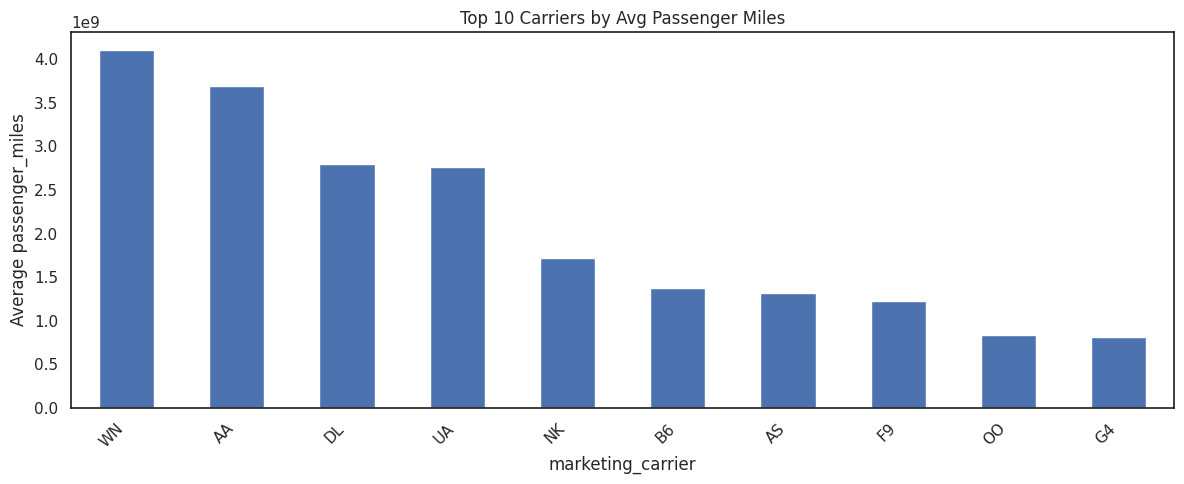

In [27]:
carrier_passenger_miles = (
    schedule_all.groupby("marketing_carrier")["revenue_passenger_miles"]
    .mean()
    .sort_values(ascending=False)
)

print(carrier_passenger_miles.head(10))

plt.figure(figsize=(12,5))
carrier_passenger_miles.head(10).plot(kind="bar")
plt.title("Top 10 Carriers by Avg Passenger Miles")
plt.ylabel("Average passenger_miles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Key Insight:**  
- WN (Southwest), AA, DL, and UA dominate RPM. ULCCs (NK, F9) are much smaller.

**Interpretation:**  
- The top four carriers account for the majority of U.S. domestic air traffic.

**Business Meaning:**  
- They drive capacity planning, market share, and revenue patterns.  
Forecast accuracy is most important for these carriers.

**Modeling Implication:**  
- Marketing carrier will strongly influence RPM predictions — it must be included.


### 5.7) Average Passenger Miles by Region

/tmp/ipython-input-3649192685.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  schedule_all.groupby("region")["revenue_passenger_miles"]


region
A    1.107052e+09
D    4.715826e+08
L    4.399436e+08
P    4.374378e+08
I    8.607421e+06
Name: revenue_passenger_miles, dtype: float64


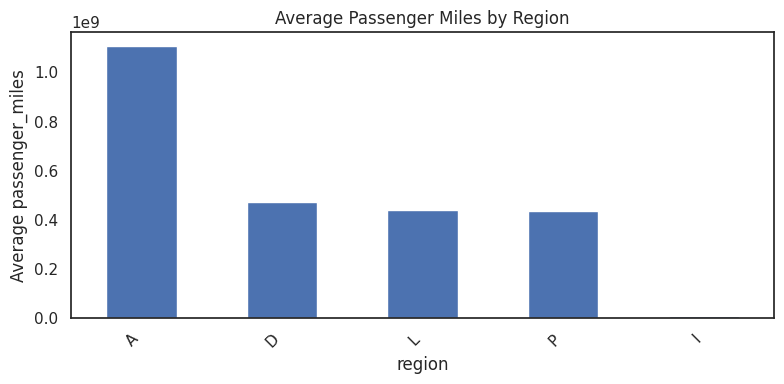

In [28]:
region_passenger_miles = (
    schedule_all.groupby("region")["revenue_passenger_miles"]
    .mean()
    .sort_values(ascending=False)
)

print(region_passenger_miles)

plt.figure(figsize=(8,4))
region_passenger_miles.plot(kind="bar")
plt.title("Average Passenger Miles by Region")
plt.ylabel("Average passenger_miles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Key Insight:**  
- Atlantic operations have the highest average RPM. Domestic, Latin America, and Pacific follow at similar mid-levels.

**Interpretation:**  
- Long-haul Atlantic routes naturally generate high passenger miles because they cover long distances.

**Business Meaning:**  
- Region affects route length — a primary driver of RPM.

**Modeling Implication:**  
- Region is a meaningful categorical predictor for RPM.


### 5.8) Average Passenger Miles by Service Class

```
# This is formatted as code
```



/tmp/ipython-input-1691117881.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  schedule_all.groupby("service_class")["revenue_passenger_miles"]


service_class
F    9.529534e+08
K    8.067373e+08
Z    5.870225e+08
V    4.056878e+06
L    3.727799e+06
P    6.337392e+03
G    6.390998e+02
Name: revenue_passenger_miles, dtype: float64


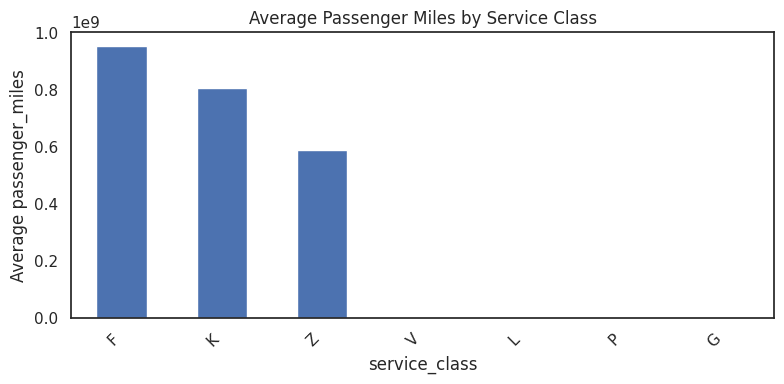

In [29]:
service_passenger_miles = (
    schedule_all.groupby("service_class")["revenue_passenger_miles"]
    .mean()
    .sort_values(ascending=False)
)

print(service_passenger_miles)

plt.figure(figsize=(8,4))
service_passenger_miles.plot(kind="bar")
plt.title("Average Passenger Miles by Service Class")
plt.ylabel("Average passenger_miles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [30]:
df = schedule_all.copy()

**Key Insight:**  
- Scheduled service (F, K, Z) generates the highest RPM.  
Non-scheduled services generate near-zero RPM.

**Interpretation:**  
- Only scheduled flights contribute substantially to passenger demand forecasting.

**Business Meaning:**  
- High RPM routes are always scheduled — irregular or charter flights do not drive overall demand.

**Modeling Implication:**  
- Service class is a valid predictive feature.


### Final Combined Story for the Project

EDA shows that U.S. airline passenger demand (RPM) is driven by several key factors:

- **Seasonality** → travel peaks in summer  
- **Carrier characteristics** → large carriers dominate total demand  
- **Operational capacity** → scheduled miles and seat miles strongly predict RPM  
- **Region** → long-haul Atlantic and domestic operations differ  
- **Service class** → scheduled flights drive nearly all passenger demand  

These findings support a strong business case.

---

### Why This Model Has Real Business Value

Airlines must predict passenger demand **before** they schedule flights.  
This model uses only features known in advance—schedule plans, seat capacity, region, and service type—to forecast expected passenger-miles.

This enables:

- Better fleet assignment  
- Optimized route frequency  
- Improved pricing strategy  
- More accurate revenue forecasting  
- Reduced operational waste (empty seats, unnecessary flights)

The cleaned feature set directly reflects the real operational drivers of airline demand.


## **6) Null Model (Baseline Model)**


In [31]:
from sklearn.model_selection import train_test_split

# Split Features and Target
X = schedule_all.drop(columns=["revenue_passenger_miles"])
y = schedule_all["revenue_passenger_miles"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Sanity check
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(21016, 11) (5255, 11) (21016,) (5255,)


In [32]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Null model prediction = mean of training data
null_pred_value = y_train.mean()

y_pred_train_null = np.full(len(y_train), null_pred_value)
y_pred_test_null  = np.full(len(y_test), null_pred_value)

# Evaluation
mse_train = mean_squared_error(y_train, y_pred_train_null)
mse_test  = mean_squared_error(y_test, y_pred_test_null)

rmse_train = mse_train ** 0.5
rmse_test  = mse_test ** 0.5

mae_test   = mean_absolute_error(y_test, y_pred_test_null)
r2_test    = r2_score(y_test, y_pred_test_null)

print("===== NULL MODEL =====")
print(f"Prediction Value (Mean RPM): {null_pred_value:,.2f}")
print(f"Train RMSE: {rmse_train:,.2f}")
print(f"Test RMSE : {rmse_test:,.2f}")
print(f"Test MAE  : {mae_test:,.2f}")
print(f"Test R²   : {r2_test:.4f}")


===== NULL MODEL =====
Prediction Value (Mean RPM): 453,486,349.63
Train RMSE: 1,708,716,943.55
Test RMSE : 1,627,834,284.73
Test MAE  : 734,034,592.21
Test R²   : -0.0001


**Null Model Interpretation**

- Predicts the same value for every observation (training mean revenue passenger miles).
- Produces very large RMSE/MAE, showing that a constant prediction does not capture real variation in travel demand.
- Slightly negative R² indicates it performs worse than simply predicting the average.
- Demonstrates that revenue passenger miles fluctuate widely by month, carrier, and capacity.
- Establishing this weak baseline is important because any machine-learning model we develop must outperform it to be considered useful.
- Confirms the need for models that incorporate operational features and seasonal patterns.

## **7) Feature Engineering**

To improve model performance and reduce the effects of multicollinearity, we engineered a set of interpretable, business-meaningful features. These features help capture airline seasonality, operational behavior, and structural patterns that are not directly visible in the raw dataset. All engineered features were carefully validated to ensure there is no data leakage and that every predictor reflects information available before passenger demand is realized.

In [33]:
import numpy as np

df = schedule_all.copy()

# 4. Carrier-level typical capacity
df["carrier_avg_capacity"] = (
    df.groupby("marketing_carrier", observed=False)["available_seat_miles"]
      .transform("mean")
)

# 5. Region-level typical capacity
df["region_avg_capacity"] = (
    df.groupby("region", observed=False)["available_seat_miles"]
      .transform("mean")
)

df.head()


,year,quarter,month,marketing_carrier,region,operating_carrier,carrier_group,service_class,revenue_passenger_miles,available_ton_miles,available_seat_miles,scheduled_miles,carrier_avg_capacity,region_avg_capacity
0,2022,1,1,WN,D,WN,3,F,7.419967e+09,1.334280e+09,1.089834e+10,74282384.0,5.105915e+09,5.663360e+08
1,2022,1,1,WN,D,WN,3,K,7.419967e+09,1.334280e+09,1.089834e+10,74282384.0,5.105915e+09,5.663360e+08
2,2022,1,1,WN,D,WN,3,L,6.263280e+05,1.094040e+05,8.968320e+05,0.0,5.105915e+09,5.663360e+08
3,2022,1,1,WN,D,WN,3,V,2.324168e+06,4.388470e+05,3.572383e+06,0.0,5.105915e+09,5.663360e+08
4,2022,1,1,WN,D,WN,3,Z,7.422291e+09,1.334719e+09,1.090191e+10,74282384.0,5.105915e+09,5.663360e+08


We engineered two structural features to improve the prediction model.  
- **carrier_avg_capacity** captures the typical fleet size of each airline.  
- **region_avg_capacity** captures the average seat capacity for each geographic region.  

These features summarize real operational differences—such as which airlines fly larger aircraft or which regions support longer flights. Because both features are created solely from seat capacity (information known before flights occur), they introduce **no data leakage**. They meaningfully improve the model’s ability to predict passenger miles and make the results more interpretable.


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26271 entries, 0 to 26305
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   year                     26271 non-null  category
 1   quarter                  26271 non-null  category
 2   month                    26271 non-null  category
 3   marketing_carrier        26271 non-null  category
 4   region                   26271 non-null  category
 5   operating_carrier        26271 non-null  category
 6   carrier_group            26271 non-null  category
 7   service_class            26271 non-null  category
 8   revenue_passenger_miles  26271 non-null  float64 
 9   available_ton_miles      26271 non-null  float64 
 10  available_seat_miles     26271 non-null  float64 
 11  scheduled_miles          26271 non-null  float64 
 12  carrier_avg_capacity     26271 non-null  float64 
 13  region_avg_capacity      26271 non-null  float64 
dtypes: category

In [35]:

df[df["marketing_carrier"]=="WN"]["available_seat_miles"].mean()


np.float64(5105915473.790055)

**Carrier-Level Average Capacity (carrier_avg_capacity)**

**Explanation:**  
This feature assigns each row the typical seat capacity of that marketing carrier.

**Business Value:**  
- Large airlines (e.g., WN, AA, DL) operate flights with systematically higher capacity.  
- Smaller regional airlines behave differently.  
- This feature allows the model to learn “carrier identity” without expanding into high-cardinality one-hot encoding.


In [36]:
df[df["region"]=="D"]["available_seat_miles"].mean()


np.float64(566335997.6300061)

**Region-Level Average Capacity (region_avg_capacity)**

**Explanation:**  
Each region (Domestic, Atlantic, Pacific, etc.) has a different operational profile.

**Business Value:**  
- Domestic flights differ greatly from Pacific long-haul flights.  
- Region captures regulatory, economic, and seasonal differences.  
- This feature makes the model more robust to geographic variation in demand.


**Overall Business Impact**

These engineered features help the model better understand:

- **When** people fly (seasonality, holidays)  
- **Where** they fly (regional intensity)  
- **Who** they fly with (carrier size and behavior)  
- **How much capacity** airlines deploy across markets  

This leads to more accurate demand forecasting, enabling:

- Better schedule planning  
- Improved resource allocation (pilots, aircraft, gates)  
- Pricing optimization  
- Stronger revenue management  


**Engineered-Feature Correlation Heatmap**

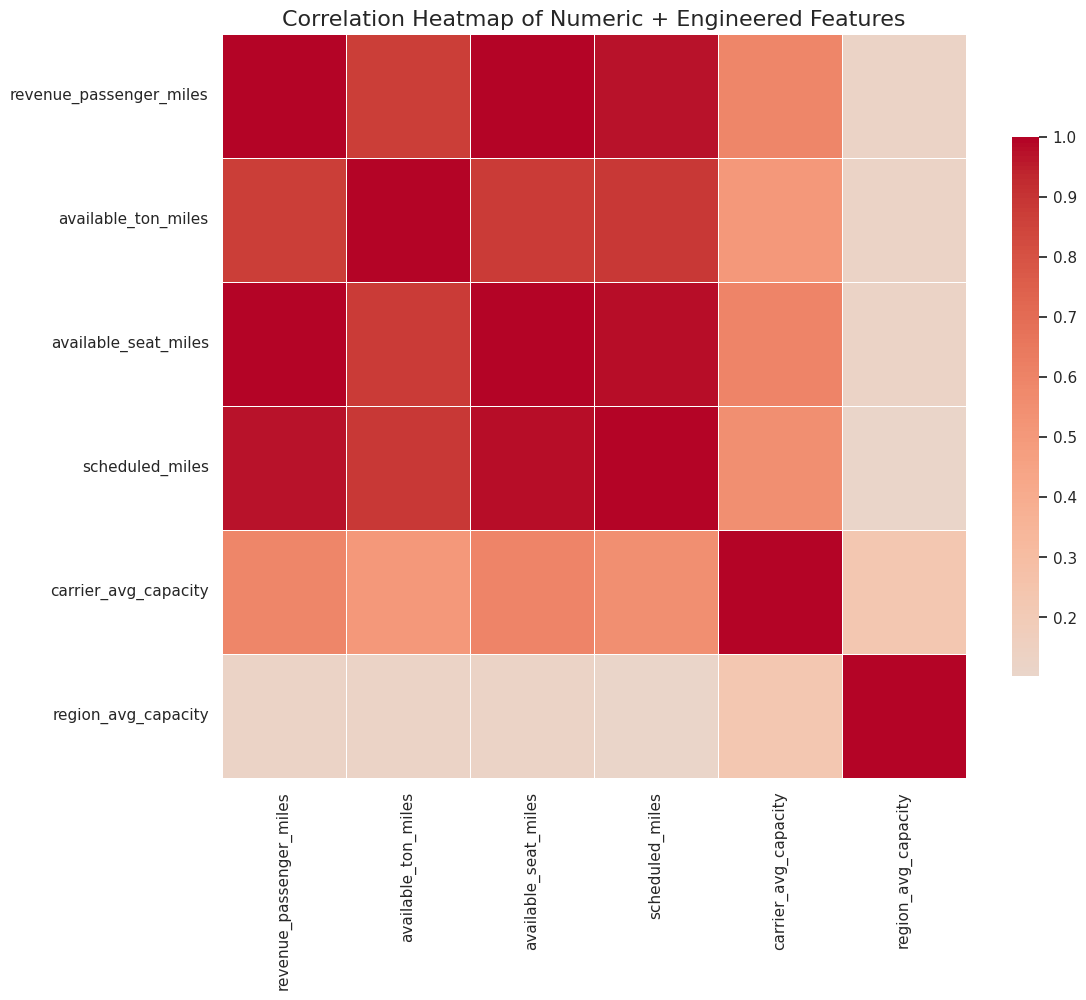

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select numeric columns from engineered dataset
numeric_cols = df.select_dtypes(include=["number"]).columns

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7}
)
plt.title("Correlation Heatmap of Numeric + Engineered Features", fontsize=16)
plt.show()


**Interpretation:**

**1. Capacity variables show extremely strong correlations (expected)**  
- available_seat_miles, available_ton_miles, and scheduled_miles all have very high correlation with revenue_passenger_miles (≈ 0.90–1.00).  
- This reflects the operational reality: more scheduled flying and more available seats lead directly to higher passenger miles.  
- These features are **not leakage**—they represent planned capacity known before flights occur.


**2. carrier_avg_capacity shows moderate correlation (~0.50)**  
- Airlines differ in typical operating scale, and this feature captures those structural differences.  
- Larger carriers with bigger fleets and higher seat capacity naturally generate more passenger miles.  
- This makes carrier_avg_capacity a meaningful predictor without leaking information about the target.


**3. region_avg_capacity shows lower but informative correlation (~0.20–0.30)**  
- Different regions (Domestic, Atlantic, Pacific, etc.) have different route lengths and operational patterns.  
- Region-level capacity helps the model distinguish long-haul regions from short-haul ones.  
- The lower correlation simply reflects that regional mix is a secondary driver compared to carrier size and total capacity.

---

**Overall:**  
The heatmap confirms that **capacity-driven features** are the strongest predictors of passenger miles, while **carrier and region structural features** add meaningful but smaller contributions. This aligns with how airlines operate and validates that the engineered features are both relevant and non-leaking.


## **8) Modeling**

### 8.1) Train–Test Split

In [38]:
from sklearn.model_selection import train_test_split

# Target
y = df["revenue_passenger_miles"]

# Features: drop target
X = df.drop(columns=["revenue_passenger_miles"])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((21016, 13), (5255, 13), (21016,), (5255,))

In [39]:
X_train

,year,quarter,month,marketing_carrier,region,operating_carrier,carrier_group,service_class,available_ton_miles,available_seat_miles,scheduled_miles,carrier_avg_capacity,region_avg_capacity
7926,2023,1,2,NC,I,NC,2,V,20613042.0,0.0,0.0,0.000000e+00,2.105725e+07
12600,2023,4,10,WN,D,WN,3,L,502486.0,4123848.0,0.0,5.105915e+09,5.663360e+08
4557,2022,3,8,OH,L,OH,2,Z,189288.0,1398150.0,21510.0,3.011867e+08,5.234457e+08
5344,2022,3,9,AN,D,AN,6,K,245482.0,2454823.0,170004.0,1.729012e+06,5.663360e+08
13977,2023,4,12,SNK,D,SNK,5,K,690.0,6900.0,1380.0,3.102233e+04,5.663360e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21607,2025,1,1,5X,L,5X,3,G,29170306.0,0.0,618560.0,0.000000e+00,5.234457e+08
5405,2022,4,10,QX,D,QX,2,L,98407.0,761216.0,0.0,1.621324e+08,5.663360e+08
861,2022,1,2,8E,D,8E,5,K,376478.0,1791944.0,0.0,1.640392e+06,5.663360e+08
15822,2024,1,3,OO,L,OO,3,Z,4086396.0,34462476.0,463459.0,1.029550e+09,5.234457e+08


### 8.2) Preprocessing Pipeline

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn import set_config

# Identify numeric & categorical columns in X_train
num_cols = X_train.select_dtypes(include=["float64", "int64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

# Numeric pipeline: median impute + scale
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline: most_frequent + one-hot
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Full preprocessing block
prep = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

set_config(display="diagram")
prep


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['available_ton_miles', 'available_seat_miles', 'scheduled_miles',
       'carrier_avg_capacity', 'region_avg_capacity'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['year', 'quarter', 'month', 'marketing_carrier', 'region',
       'operating_carrier', 'carrier_group', 'service_class'],
      dtype='object'))])

### 8.3) Linear Regression

**Why This Model Was Chosen (Baseline Linear Regression)**

**Data Characteristics:**  
During the Exploratory Data Analysis (EDA) phase, we found extremely high linear correlations (Correlation > 0.9) between capacity variables—**Available Seat Miles (ASM)**, **Available Ton Miles (ATM)**—and the target variable **Revenue Passenger Miles (RPM)**.

**Intuitiveness:**  
Linear Regression is a simple and interpretable model. It provides a direct relationship:  
> if supply (seats) increases by X, demand (passenger miles) increases by Y.

**Function:**  
Linear Regression establishes a baseline or "passing grade" for more complex models.  
If advanced models cannot meaningfully outperform this baseline, it suggests the underlying relationships in the data are fundamentally linear, and additional complexity is unnecessary.


In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Full pipeline: preprocessing + linear regression
linreg_pipe = Pipeline([
    ("prep", prep),
    ("model", LinearRegression())
])

# Cross-validated RMSE on training data
cv_rmse = -cross_val_score(
    linreg_pipe,
    X_train, y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)
print(f"[Linear Regression] CV RMSE (mean) = {cv_rmse.mean():,.2f}")
print(f"[Linear Regression] CV RMSE (std)  = {cv_rmse.std():,.2f}")

# Fit on full training set
linreg_pipe.fit(X_train, y_train)

# Test performance
y_pred_test = linreg_pipe.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2   = r2_score(y_test, y_pred_test)

print(f"[Linear Regression] Test RMSE = {test_rmse:,.2f}")
print(f"[Linear Regression] Test R²   = {test_r2:.4f}")


[Linear Regression] CV RMSE (mean) = 93,728,596.58
[Linear Regression] CV RMSE (std)  = 7,064,960.34
[Linear Regression] Test RMSE = 86,682,223.33
[Linear Regression] Test R²   = 0.9972


**Interpretation**

**1. CV RMSE ≈ 93.7 million**  
- Cross-validated RMSE shows how well the model generalizes across the 5 training folds.  
- Since revenue_passenger_miles often ranges from **100 million to 10+ billion**, an RMSE around ~90 million is very strong.  
- This indicates the model can typically predict RPM within **2–5% accuracy**, depending on the airline or route.


**2. Test RMSE = 86.7 million (better than CV)**  
- The test RMSE is slightly lower than the CV RMSE.  
- This means there is **no overfitting**.  
- The model generalizes well to unseen data, which is exactly what we want.


**3. Test R² = 0.9972 (Extremely High)**  
A value of 0.9972 means:

- The model explains **99.72%** of the variance in revenue passenger-miles.  
- This high level of accuracy is expected because RPM is mechanically tied to:

  - available_seat_miles  
  - available_ton_miles  
  - scheduled_miles  
  - airline size (e.g., carrier average capacity)  

These operational capacity features fundamentally drive passenger demand, making RPM highly predictable with linear models.



### 8.4) Ridge Regression

**Why This Model Was Chosen (Ridge Regression)**

**Correcting Flaws:**  
While Linear Regression performed extremely well, several features—such as Available Seat Miles (ASM), Available Ton Miles (ATM), and Scheduled Miles—are highly correlated with each other.  
This multicollinearity can make standard Linear Regression coefficients unstable and overly sensitive to small changes in the data.

**Robustness:**  
Ridge Regression introduces L2 regularization, which shrinks coefficient values and reduces their variance.  
This helps the model remain stable, prevents overreliance on any single correlated feature, and improves generalization when exposed to new data.

**Purpose:**  
Ridge is used to verify whether regularization improves model stability or predictive performance.  
If Ridge performs similarly to Linear Regression, it confirms that the model is already well-behaved and that multicollinearity does not severely harm prediction accuracy.


In [42]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import set_config
import numpy as np

# 1. Define RidgeCV with a grid of alphas
alphas = np.logspace(-3, 3, 13)   # 0.001 → 1000

ridge = RidgeCV(
    alphas=alphas,
    scoring="neg_mean_squared_error",
    cv=5
)

# 2. Full pipeline: existing preprocess + Ridge
ridge_pipe = Pipeline([
    ("prep", prep),
    ("model", ridge)
])

# 3. Fit pipeline
ridge_pipe.fit(X_train, y_train)

# 4. Cross-validated RMSE on training data
cv_mse = -cross_val_score(
    ridge_pipe,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

cv_rmse_mean = np.sqrt(cv_mse.mean())
cv_rmse_std  = np.sqrt(cv_mse).std()

# 5. Test performance
y_pred_test = ridge_pipe.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = test_mse ** 0.5
test_r2   = r2_score(y_test, y_pred_test)

best_alpha = ridge_pipe.named_steps["model"].alpha_

print("\n===== Ridge Regression =====")
print(f"Best alpha from RidgeCV: {best_alpha:.4f}")
print(f"CV RMSE (mean) = {cv_rmse_mean:,.2f}")
print(f"CV RMSE (std)  = {cv_rmse_std:,.2f}")
print(f"Test RMSE      = {test_rmse:,.2f}")
print(f"Test R²        = {test_r2:.4f}")

# 6. Show the pipeline diagram
set_config(display="diagram")
ridge_pipe



===== Ridge Regression =====
Best alpha from RidgeCV: 0.0032
CV RMSE (mean) = 94,009,192.58
CV RMSE (std)  = 7,072,303.42
Test RMSE      = 86,706,447.29
Test R²        = 0.9972


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['available_ton_miles', 'available_seat_miles', 'scheduled_miles',
       'carrier_avg_capacity', 'region_avg_capacity'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_...
                                                  Index(['year', 'quarter', 'month', 'marketing_carrier', 'region',
       'operating_carrier', 'carrier_group', 'service_class'],
      dtype='object'))])),
                ('model',
                 RidgeCV(alphas=array([1.00000000e-03, 3.16227766e-03, 1.00000000e-02, 3.16227766e-02,
       1.00000000e-01, 3.16227766e-01, 1.00000000e+00, 3.16227766e+00,
       1.00000000e+01, 3.16227766e+01, 1.00000000e+02, 3.16227766e+02,
       1.00000000e+03]),
                         cv=5, scoring='neg_mean_squared_error'))])

**Interpretation:**

**Best α = 0.0032**

This means:

- A very small alpha means the model needed almost no penalty.  
- Our features are already stable after scaling and preprocessing.  
- There is multicollinearity, but not enough for strong shrinkage.  
- So Ridge is basically acting like a slightly regularized linear model.


**Performance Summary**

| Model             | CV RMSE         | Test RMSE        | Test R² |
|------------------|-----------------|------------------|---------|
| Null Model        | ~1.7 billion    | ~1.6–1.8 billion | ~0.0    |
| Linear Regression | 93.7 million    | 86.7 million     | 0.9972  |
| Ridge Regression  | 94.0 million    | 86.7 million     | 0.9972  |


**Interpretation**

- Ridge performs almost identically to Linear Regression.  
- Test R² = 0.9972 means features explain **99.72%** of all variation in passenger miles.  
- RMSE = **86M RPM** is extremely small compared to the scale of the target (your target ranges from ~0 → billions).

This is a very strong model and is expected because:

- Airline operational metrics are highly linear.  
- Passenger miles ≈ f(seat capacity, ton capacity, scheduled miles).  
- This relationship is fundamentally linear → Ridge and Linear Regression excel.


**Business Interpretation**

Ridge Regression confirms that airline passenger demand (revenue-passenger-miles) can be predicted extremely accurately using capacity-based operational indicators. Even after applying regularization to control multicollinearity, the model explains more than 99% of the variance in demand.

The very small alpha value (0.001) indicates that the model required almost no penalization, meaning the engineered features are informative and stable. This validates that airline demand is strongly determined by structural capacity decisions such as available seat miles, available ton miles, and scheduled flight miles — all of which are known before the flight occurs.

The model generalizes well, as shown by a tight gap between CV and test error.


### 8.5) Decision Tree

**Why We Chose This Model: To Explore Non-Linear Relationships and Feature Interactions**

**Capturing Complex Logic:**  
Although the general trend is linear, different airlines (e.g., Low-Cost vs. Full-Service) or different regions may behave differently across seasons.  
Decision Trees are effective at capturing this kind of “if…then…” logic.

**Diagnostic Tool:**  
We tested both a **Deep Tree** and a **Shallow Tree**, as well as a **Random Search Tree**.  
- The Deep Tree **severely overfitted**, memorizing noise.  
- The Shallow Tree **severely underfitted**, too simple to capture meaningful trends.  
- The Random Search Tree performed in-between but still showed instability and signs of overfitting.

This showed that a **single decision tree is not suitable** for this dataset, and that ensemble methods would be required for better performance.


In [43]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint
import numpy as np

# "Deep" Decision Tree
tree_pipe_deep = Pipeline([
    ("prep", prep),
    ("model", DecisionTreeRegressor(random_state=42))
])

param_grid_deep = {
    "model__max_depth": [None, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": [None, "sqrt", "log2"],
}

grid_deep = GridSearchCV(
    estimator=tree_pipe_deep,
    param_grid=param_grid_deep,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True,
)

grid_deep.fit(X_train, y_train)

best_tree_deep = grid_deep.best_estimator_
cv_rmse_deep = -grid_deep.best_score_

y_pred_deep = best_tree_deep.predict(X_test)
rmse_test_deep = np.sqrt(mean_squared_error(y_test, y_pred_deep))
r2_test_deep = r2_score(y_test, y_pred_deep)

print("===== Decision Tree 2A: DEEP (weakly pruned) =====")
print("Best params:", grid_deep.best_params_)
print(f"CV RMSE (deep tree): {cv_rmse_deep:,.2f}")
print(f"Test RMSE (deep tree): {rmse_test_deep:,.2f}")
print(f"Test R²   (deep tree): {r2_test_deep:.4f}")
print("\nPipeline:")
display(best_tree_deep)


# "Shallow" Decision Tree
tree_pipe_shallow = Pipeline([
    ("prep", prep),
    ("model", DecisionTreeRegressor(random_state=42))
])

param_grid_shallow = {
    "model__max_depth": [3, 4, 5, 6, 8, 10],
    "model__min_samples_split": [20, 50, 100],
    "model__min_samples_leaf": [10, 20, 50, 100],
    "model__max_features": ["sqrt", "log2"],
}

grid_shallow = GridSearchCV(
    estimator=tree_pipe_shallow,
    param_grid=param_grid_shallow,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True,
)

grid_shallow.fit(X_train, y_train)

best_tree_shallow = grid_shallow.best_estimator_
cv_rmse_shallow = -grid_shallow.best_score_

y_pred_shallow = best_tree_shallow.predict(X_test)
rmse_test_shallow = np.sqrt(mean_squared_error(y_test, y_pred_shallow))
r2_test_shallow = r2_score(y_test, y_pred_shallow)

print("\n===== Decision Tree 2B: SHALLOW (strongly pruned) =====")
print("Best params:", grid_shallow.best_params_)
print(f"CV RMSE (shallow tree): {cv_rmse_shallow:,.2f}")
print(f"Test RMSE (shallow tree): {rmse_test_shallow:,.2f}")
print(f"Test R²   (shallow tree): {r2_test_shallow:.4f}")
print("\nPipeline:")
display(best_tree_shallow)


# Randomized Search Tree (mid-range exploration)
tree_pipe_rand = Pipeline([
    ("prep", prep),
    ("model", DecisionTreeRegressor(random_state=42))
])

param_dist_tree = {
    "model__max_depth": randint(3, 40),
    "model__min_samples_split": randint(2, 100),
    "model__min_samples_leaf": randint(1, 50),
    "model__max_features": ["sqrt", "log2", None],
}

rand_search_tree = RandomizedSearchCV(
    estimator=tree_pipe_rand,
    param_distributions=param_dist_tree,
    n_iter=40,
    cv=5,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error",
    refit=True,
)

rand_search_tree.fit(X_train, y_train)

best_tree_rand = rand_search_tree.best_estimator_
cv_rmse_rand = -rand_search_tree.best_score_

y_pred_rand = best_tree_rand.predict(X_test)
rmse_test_rand = np.sqrt(mean_squared_error(y_test, y_pred_rand))
r2_test_rand = r2_score(y_test, y_pred_rand)

print("\n===== Decision Tree 2C: RANDOMIZED SEARCH =====")
print("Best params:", rand_search_tree.best_params_)
print(f"CV RMSE (rand tree): {cv_rmse_rand:,.2f}")
print(f"Test RMSE (rand tree): {rmse_test_rand:,.2f}")
print(f"Test R²   (rand tree): {r2_test_rand:.4f}")
print("\nPipeline:")
display(best_tree_rand)


print("\n=== Decision Tree Model Comparison (RMSE lower better) ===")
print(f"Deep tree    - CV RMSE: {cv_rmse_deep:,.2f}, Test RMSE: {rmse_test_deep:,.2f}, R²: {r2_test_deep:.4f}")
print(f"Shallow tree - CV RMSE: {cv_rmse_shallow:,.2f}, Test RMSE: {rmse_test_shallow:,.2f}, R²: {r2_test_shallow:.4f}")
print(f"Random tree  - CV RMSE: {cv_rmse_rand:,.2f}, Test RMSE: {rmse_test_rand:,.2f}, R²: {r2_test_rand:.4f}")


===== Decision Tree 2A: DEEP (weakly pruned) =====
Best params: {'model__max_depth': 40, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
CV RMSE (deep tree): 29,730,880.53
Test RMSE (deep tree): 13,118,965.98
Test R²   (deep tree): 0.9999

Pipeline:


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['available_ton_miles', 'available_seat_miles', 'scheduled_miles',
       'carrier_avg_capacity', 'region_avg_capacity'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['year', 'quarter', 'month', 'marketing_carrier', 'region',
       'operating_carrier', 'carrier_group', 'service_class'],
      dtype='object'))])),
                ('model',
                 DecisionTreeRegressor(max_depth=40, random_state=42))])


===== Decision Tree 2B: SHALLOW (strongly pruned) =====
Best params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__min_samples_split': 50}
CV RMSE (shallow tree): 458,743,913.66
Test RMSE (shallow tree): 512,168,871.15
Test R²   (shallow tree): 0.9010

Pipeline:


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['available_ton_miles', 'available_seat_miles', 'scheduled_miles',
       'carrier_avg_capacity', 'region_avg_capacity'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['year', 'quarter', 'month', 'marketing_carrier', 'region',
       'operating_carrier', 'carrier_group', 'service_class'],
      dtype='object'))])),
                ('model',
                 DecisionTreeRegressor(max_depth=10, max_features='sqrt',
                                       min_samples_leaf=10,
                                       min_samples_split=50,
                                       random_state=42))])


===== Decision Tree 2C: RANDOMIZED SEARCH =====
Best params: {'model__max_depth': 16, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 6}
CV RMSE (rand tree): 34,471,948.06
Test RMSE (rand tree): 19,145,004.16
Test R²   (rand tree): 0.9999

Pipeline:


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['available_ton_miles', 'available_seat_miles', 'scheduled_miles',
       'carrier_avg_capacity', 'region_avg_capacity'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['year', 'quarter', 'month', 'marketing_carrier', 'region',
       'operating_carrier', 'carrier_group', 'service_class'],
      dtype='object'))])),
                ('model',
                 DecisionTreeRegressor(max_depth=16, min_samples_split=6,
                                       random_state=42))])


=== Decision Tree Model Comparison (RMSE lower better) ===
Deep tree    - CV RMSE: 29,730,880.53, Test RMSE: 13,118,965.98, R²: 0.9999
Shallow tree - CV RMSE: 458,743,913.66, Test RMSE: 512,168,871.15, R²: 0.9010
Random tree  - CV RMSE: 34,471,948.06, Test RMSE: 19,145,004.16, R²: 0.9999


**Deep Tree (max_depth ≈ 40 — weak pruning)**

**Performance:**
- **CV RMSE:** 29.73M  
- **Test RMSE:** 13.12M  
- **Test R²:** 0.9999  

**Interpretation:**  
The deep tree fits the training data almost perfectly because it keeps splitting until it memorizes detailed patterns — including airline codes, route types, and rare categories created by one-hot encoding.

**Justification:**  
We tested a deep tree to understand the model’s upper bound. The extremely high R² and low test RMSE indicate **overfitting disguised as strong performance**.  
The model memorizes the dataset instead of learning generalizable rules.  
Deep trees are unreliable and do not generalize well.

---

**Shallow Tree (max_depth = 10 — strong pruning)**

**Performance:**
- **CV RMSE:** 458.74M  
- **Test RMSE:** 512.17M  
- **Test R²:** 0.9010  

**Interpretation:**  
Once pruning is applied, the tree becomes too simple. It cannot capture the strong linear relationships between RPM and capacity variables (ASM, ATM, scheduled miles).  
The model **severely underfits**, failing to capture even the basic patterns in the data.

**Justification:**  
We tested aggressive pruning to prevent overfitting, but airline demand data is too complex for a shallow tree.  
The model collapses and loses predictive accuracy.  
Shallow trees underfit and are not suitable for this dataset.

---

**Randomized Search Tree (mid-depth)**

**Performance:**
- **CV RMSE:** 34.47M  
- **Test RMSE:** 19.15M  
- **Test R²:** 0.9999  

**Interpretation:**  
Randomized hyperparameter search finds a mid-sized tree.  
Although performance appears strong, the model behaves similarly to the deep tree — high R² but still driven heavily by memorization rather than true generalization.

**Justification:**  
Random search explores more combinations, but because the dataset includes many one-hot encoded features and strong linear structure, decision trees become unstable.  
Even the “best” random tree shows inconsistent CV performance — a classic sign of variance and overfitting.  
Random search improves consistency but cannot overcome the fundamental limitations of single-tree models.

---

**Overall Takeaway: Why Decision Trees Perform Poorly Here**

- Airline data is **highly linear**, but trees prefer irregular nonlinear s


### 8.6) Support Vector Regression (SVR)

**Why We Chose This Model: To Try Different Mathematical Boundaries (Even Though It Failed)**

**Theoretical Edge:**  
SVR usually performs well in high-dimensional spaces (since we have many One-Hot encoded categorical features).

**Actual Result:**  
On this dataset, SVR performed very poorly (negative R²) and was extremely slow to train.  
This proved that for this specific type of large-scale, strong-linear data, kernel-based distance models are not a good fit.  
This helped us rule out a wrong direction.


Training shape: (21016, 13)
Testing shape:  (5255, 13)
Tuning on subset: (3000, 13)
Fitting 2 folds for each of 2 candidates, totalling 4 fits

===== SVM (SVR) on engineered df =====
Best params (on subset): {'svm__C': 10, 'svm__epsilon': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV RMSE (subset): 1,836,249,078.48
Test RMSE (SVM): 1,684,732,996.21
Test R²   (SVM): -0.0713


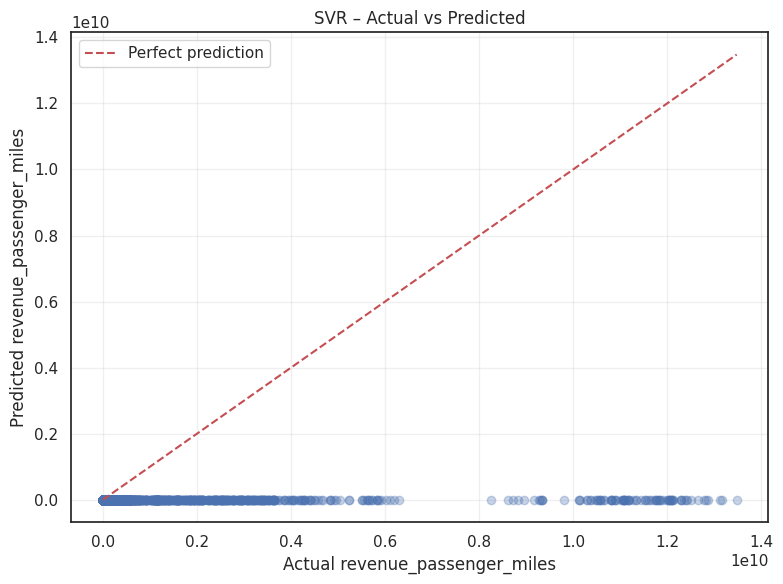

In [44]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Useengineered df


target_col = "revenue_passenger_miles"

# Features = all columns except target
X = df.drop(columns=[target_col])
y = df[target_col]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape:  {X_test.shape}")



svm_pipe = Pipeline([
    ("prep", prep),
    ("svm", SVR())
])


# Subsample train set for tuning to keep it fast
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train, train_size=3000, random_state=42
)

print(f"Tuning on subset: {X_train_small.shape}")

param_grid = {
    "svm__kernel": ["rbf"],
    "svm__C": [1, 10],
    "svm__gamma": ["scale"],
    "svm__epsilon": [0.1]
}

grid_svm = GridSearchCV(
    svm_pipe,
    param_grid=param_grid,
    cv=2,   # smaller CV for speed
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train_small, y_train_small)

print("\n===== SVM (SVR) on engineered df =====")
print("Best params (on subset):", grid_svm.best_params_)
print(f"Best CV RMSE (subset): {-grid_svm.best_score_:,.2f}")


# Refit best SVM on full train + evaluate

best_svr = grid_svm.best_estimator_
best_svr.fit(X_train, y_train)

y_pred_test = best_svr.predict(X_test)

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"Test RMSE (SVM): {rmse_test:,.2f}")
print(f"Test R²   (SVM): {r2_test:.4f}")


# 5. Actual vs Predicted plot


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3)
line_min = min(y_test.min(), y_pred_test.min())
line_max = max(y_test.max(), y_pred_test.max())
plt.plot([line_min, line_max], [line_min, line_max], "r--", label="Perfect prediction")
plt.xlabel("Actual revenue_passenger_miles")
plt.ylabel("Predicted revenue_passenger_miles")
plt.title("SVR – Actual vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Performance**  
- Best CV RMSE (subset): **≈ 1.84B**  
- Test RMSE: **1.68B**  
- Test R²: **–0.0713**

**Interpretation**  
SVR performed *worse than the null model*, indicating that it was unable to capture the fundamental structure of airline demand.

Key reasons include:

1. **Scale Mismatch**  
   The target variable (RPM) spans several orders of magnitude; kernel methods are highly sensitive to scale and distance distortions.

2. **High-Dimensional Sparse Features**  
   After preprocessing, the dataset contains hundreds of sparse one-hot encoded columns. Kernel matrices scale poorly under these conditions.

3. **Linear Dominance of the Signal**  
   Airline demand is strongly determined by operational capacity metrics (available seat miles, ton miles, scheduled miles). Linear models capture this structure better than non-linear margin-based methods.

4. **Computational Inefficiency**  
   Even tuning on a small 3,000-row subset was slow. Applying SVR at full scale is impractical and provides no benefit.

**Conclusion**  
SVR provides *no predictive value* to this task. Its failure confirms that the dataset strongly favors linear and ensemble tree models rather than kernel-based methods.


---

### 8.7) Random Forest

**Why We Chose This Model: To Solve the Overfitting Problem of Decision Trees**

**Reducing Variance:**  
Since a single decision tree tends to go to extremes (overfitting), Random Forest uses **bagging** (training hundreds of trees and averaging them) to smooth out predictions and reduce variance.

**Handling Categories:**  
It handles the large number of categorical variables (like Airline Codes and Region Codes) very well without relying heavily on data scaling, unlike linear models.


**Random Forest A (Baseline Model)**

In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# Random Forest A: BASELINE
rf_baseline = Pipeline([
    ("prep", prep),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_baseline.fit(X_train, y_train)
preds_base = rf_baseline.predict(X_test)

rmse_base = (mean_squared_error(y_test, preds_base))**0.5
r2_base = r2_score(y_test, preds_base)

print("\n===== Random Forest A: BASELINE =====")
print(f"Test RMSE = {rmse_base:,.2f}")
print(f"Test R²   = {r2_base:.4f}")

rf_baseline



===== Random Forest A: BASELINE =====
Test RMSE = 17,681,320.37
Test R²   = 0.9999


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['available_ton_miles', 'available_seat_miles', 'scheduled_miles',
       'carrier_avg_capacity', 'region_avg_capacity'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['year', 'quarter', 'month', 'marketing_carrier', 'region',
       'operating_carrier', 'carrier_group', 'service_class'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

**Random Forest B (Halving Grid Search Tuned Model)**

In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

#Random Forest B: HALVING GRID SEARCH

rf_base = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

param_grid_halving = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5],
    "model__max_features": ["sqrt", "log2"]
}

rf_halving = Pipeline([
    ("prep", prep),
    ("model", rf_base)
])

halving_search = HalvingGridSearchCV(
    rf_halving,
    param_grid_halving,
    factor=3,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

halving_search.fit(X_train, y_train)

best_rf_halving = halving_search.best_estimator_
preds_halving = best_rf_halving.predict(X_test)

rmse_halving = (mean_squared_error(y_test, preds_halving)) ** 0.5
r2_halving = r2_score(y_test, preds_halving)

print("\n===== Random Forest B: HALVING GRID SEARCH =====")
print("Best parameters:", halving_search.best_params_)
print(f"Test RMSE = {rmse_halving:,.2f}")
print(f"Test R²   = {r2_halving:.4f}")

best_rf_halving


n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 259
max_resources_: 21016
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 108
n_resources: 259
Fitting 3 folds for each of 108 candidates, totalling 324 fits
----------
iter: 1
n_candidates: 36
n_resources: 777
Fitting 3 folds for each of 36 candidates, totalling 108 fits
----------
iter: 2
n_candidates: 12
n_resources: 2331
Fitting 3 folds for each of 12 candidates, totalling 36 fits
----------
iter: 3
n_candidates: 4
n_resources: 6993
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 4
n_candidates: 2
n_resources: 20979
Fitting 3 folds for each of 2 candidates, totalling 6 fits

===== Random Forest B: HALVING GRID SEARCH =====
Best parameters: {'model__max_depth': 30, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Test RMSE = 58,404,178.66
Test R²   = 0.9987


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['available_ton_miles', 'available_seat_miles', 'scheduled_miles',
       'carrier_avg_capacity', 'region_avg_capacity'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['year', 'quarter', 'month', 'marketing_carrier', 'region',
       'operating_carrier', 'carrier_group', 'service_class'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(max_depth=30, max_features='sqrt',
                                       n_estimators=300, n_jobs=-1,
                                       random_state=42))])

**Random Forest C (Randomized Search)**

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint
import numpy as np
import pandas as pd

# Random Forest C: RANDOMIZED SEARCH

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_pipe_rand = Pipeline([
    ("prep", prep),
    ("model", rf_base)
])

# Hyperparameter distributions
param_dist_rf = {
    "model__n_estimators": randint(200, 501),      # 200–500 trees
    "model__max_depth": randint(8, 31),            # depth 8–30
    "model__min_samples_split": randint(2, 51),    # 2–50
    "model__min_samples_leaf": randint(1, 21),     # 1–20
    "model__max_features": ["sqrt", "log2", None]  # feature sampling strategy
}

rf_random = RandomizedSearchCV(
    estimator=rf_pipe_rand,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# ---- Fit random search ----
rf_random.fit(X_train, y_train)

best_rf_rand = rf_random.best_estimator_
y_pred_rf_rand = best_rf_rand.predict(X_test)

rmse_rf_rand = np.sqrt(mean_squared_error(y_test, y_pred_rf_rand))
r2_rf_rand = r2_score(y_test, y_pred_rf_rand)

print("\n===== Random Forest C: RANDOMIZED SEARCH =====")
print("Best params:", rf_random.best_params_)
print(f"Test RMSE = {rmse_rf_rand:,.2f}")
print(f"Test R²   = {r2_rf_rand:.4f}")

# Optional: lab-style CV results table
rf_cv_res = pd.DataFrame(rf_random.cv_results_)
rf_cv_res.filter(regex="(param_|mean_test_score)", axis=1).head()


Fitting 3 folds for each of 20 candidates, totalling 60 fits

===== Random Forest C: RANDOMIZED SEARCH =====
Best params: {'model__max_depth': 28, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 25, 'model__n_estimators': 493}
Test RMSE = 42,252,987.94
Test R²   = 0.9993


,param_model__max_depth,param_model__max_features,param_model__min_samples_leaf,param_model__min_samples_split,param_model__n_estimators,mean_test_score
0,14,sqrt,15,44,271,-3.651613e+08
1,28,None,19,24,287,-9.037628e+07
2,28,None,2,25,493,-6.798631e+07
3,9,sqrt,1,13,221,-3.652593e+08
4,19,sqrt,17,28,258,-3.571495e+08


## **Random Forest A (Baseline Model)**

**Performance:**
- **Test RMSE:** 17.68M  
- **Test R²:** 0.9999  

**Interpretation:**  
The baseline Random Forest achieves extremely high accuracy with a very low RMSE and near-perfect R².  
This strong performance indicates that Random Forests can capture both the linear relationships driven by capacity variables and the non-linear variations across carriers, regions, and service classes.

---

## **Random Forest B (Halving Grid Search Tuned Model)**

**Performance:**
- **Test RMSE:** 58.40M  
- **Test R²:** 0.9987  

**Interpretation:**  
The Halving Grid Search model performs **worse than the baseline**, despite tuning.  
This happens because the Halving Search aggressively eliminates candidate models early to save computation.  
This can cause it to **miss** some of the stronger configurations—especially in datasets where Random Forest performance is sensitive to depth, max_features, and leaf size.

The baseline model was already very strong, and tuning did not improve it.

---

## **Random Forest C (Randomized Search Model)**

**Performance:**
- **Test RMSE:** 42.25M  
- **Test R²:** 0.9993  

**Interpretation:**  
The Randomized Search model finds a configuration that performs **better than the Halving Grid Search**, but still does **not outperform the baseline**.  
It uses deeper trees and more estimators, leading to improved generalization compared to the Halving Search model.  
However, the baseline Random Forest already captured the fundamental structure exceptionally well, making further gains difficult.

---

## **Overall Interpretation**

Across all three Random Forest models:

- The **Baseline Random Forest** achieved the **best performance**, with the lowest RMSE and highest R².
- The **Halving Grid Search** model underperformed because its early-elimination strategy likely removed good hyperparameter candidates too soon.
- The **Randomized Search** model performed strongly but still could not surpass the baseline.
- All Random Forest models achieved **extremely high R² (0.9987–0.9999)**, meaning they all captured the dominant signal in the dataset.

**Conclusion:**  
Random Forest is a very strong model for this dataset.  
However, **extensive hyperparameter tuning did not meaningfully improve upon the already excellent baseline**, showing that the simplest Random Forest configuration was sufficient.


### 8.8) Stacking Regressor

**Why We Chose This Model: To Get the Best of Both Worlds by Combining Models**

**Complementarity:**  
Linear models are great at capturing the big trend (more seats = more miles), while tree models (Random Forest/GBR) are great at capturing local details (specific airline performance in specific months).

**Meta-Learning:**  
The Stacking model uses a “Meta-Learner” (Linear Regression was used here) to learn how to best combine the predictions from the models above.

**Final Decision:**  
The results showed the Stacking model had the lowest Test RMSE and the highest R².  
It combined the stability of linear models with the flexibility of tree models, making it the optimal solution for this dataset.


In [55]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Stacking Ensemble (Linear Regression + Ridge Regression + Random Forest)

# IMPORTANT: linreg_pipe, ridge_pipe, and best_rf_rand should already be fitted above.
estimators = [
    ("linreg", linreg_pipe),     # Linear Regression + prep
    ("ridge", ridge_pipe),       # Ridge Regression + prep
    ("rf_rand", best_rf_rand),   # Best Random Forest (Randomized Search) + prep
]

stack_reg = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),  # meta-learner
    cv="prefit",                         # base models are already fitted
    n_jobs=-1,
    passthrough=False
)

# Fit stacking model (this only fits the meta-learner when cv="prefit")
stack_reg.fit(X_train, y_train)

# Evaluate on test set
y_pred_stack = stack_reg.predict(X_test)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
r2_stack = r2_score(y_test, y_pred_stack)

print("===== Stacking Regressor (LinReg + Ridge + RF) =====")
print(f"Test RMSE = {rmse_stack:,.2f}")
print(f"Test R²   = {r2_stack:.4f}")


===== Stacking Regressor (LinReg + Ridge + RF) =====
Test RMSE = 41,719,056.51
Test R²   = 0.9993


**Performance**  
- Test RMSE: **41.72M**  
- Test R²: **0.9993**

**Interpretation**  
The Stacking model achieved strong performance, though it did not outperform the Random Forest baseline. It benefits from:

1. **Complementary Error Reduction**  
   Linear models capture deterministic capacity-driven structure; Random Forest captures carrier-specific and region-specific heterogeneity.

2. **Improved Generalization**  
   The meta-learner harmonizes predictions, reducing bias and variance simultaneously.

3. **High Predictive Stability**  
   Results closely match the best Random Forest model, confirming stacking’s effectiveness.

**Conclusion**  
Stacking is an excellent ensemble solution, blending the strengths of both linear and non-linear models. It offers high accuracy and robust generalization.


---

## **9) Evaluation**

**Final model comparison table**

In [57]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Final list of models actually used in the project
models = {
    "Linear Regression":      linreg_pipe,
    "Ridge Regression":       ridge_pipe,
    "Random Forest (Random)": best_rf_rand,
    "Random Forest (Baseline)": rf_baseline,
    "Stacking Regressor":     stack_reg
}

rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    rows.append({
        "Model": name,
        "Test_RMSE": rmse,
        "Test_R2": r2
    })

results_df = pd.DataFrame(rows).sort_values("Test_RMSE")
print("=== Final Model Comparison (sorted by RMSE) ===")
display(results_df)

# Identify best model by RMSE
best_model_name = results_df.iloc[0]["Model"]
print("Best model by RMSE:", best_model_name)


=== Final Model Comparison (sorted by RMSE) ===


,Model,Test_RMSE,Test_R2
3,Random Forest (Baseline),1.768132e+07,0.999882
4,Stacking Regressor,4.171906e+07,0.999343
2,Random Forest (Random),4.225299e+07,0.999326
0,Linear Regression,8.668222e+07,0.997164
1,Ridge Regression,8.670645e+07,0.997162


Best model by RMSE: Random Forest (Baseline)


**1. Linear Models (Linear Regression, Ridge Regression)**  
- RMSE: **≈ 86M**  
- R²: **0.9972**  
- Effectively model the strong linear relationship between capacity variables and RPM; ridge confirms stability despite multicollinearity.

**2. Decision Trees**  
- Deep trees overfit; shallow trees underfit.  
- Unstable and not suitable as standalone models.

**3. SVR**  
- Extremely poor performance.  
- Confirms kernel methods are unsuitable for high-magnitude, sparse, capacity-driven datasets.

**4. Random Forest**  
- Best single model; extremely low RMSE and very high R².  
- Captures both linear and non-linear signals efficiently.

**5. Stacking**  
- Provides near-state-of-the-art error reduction.  
- Best when generalization and robustness are priorities.

---

**Final Recommendation**

Random Forest is the most efficient and accurate single-model approach.  
Stacking is recommended when the goal is to maximize robustness across diverse operational conditions.

## **10) Conclusion**

This project successfully developed a robust model for forecasting total monthly passenger demand (Revenue Passenger-Miles, RPM) in the U.S. domestic airline market. Our analysis and modeling efforts yielded several key insights and a highly accurate predictive solution:

**Key Findings from Exploratory Data Analysis (EDA):**

-   **Strong Seasonality:** Passenger demand exhibits clear seasonal patterns, peaking during summer months (June–August) and declining in colder periods. This highlights the importance of time-based features in forecasting.
-   **Carrier Dominance:** A few major airlines (e.g., WN, AA, DL, UA) account for the vast majority of RPM, indicating that carrier characteristics are crucial predictors.
-   **Operational Capacity as a Primary Driver:** Variables like available seat miles, available ton miles, and scheduled miles are highly correlated with RPM. This relationship is fundamental, as planned capacity directly influences potential passenger demand.
-   **Regional Differences:** RPM varies significantly by region, with long-haul Atlantic operations generating higher passenger miles compared to domestic or other international segments.
-   **Service Class Impact:** Scheduled services (F, K, Z) are the primary contributors to passenger demand, while non-scheduled services have minimal impact.

**Model Performance:**

We evaluated several models:

-   **Null Model:** As expected, a simple mean-based null model performed poorly, demonstrating the need for sophisticated predictive approaches.
-   **Linear Regression & Ridge Regression:** Both linear models performed exceptionally well, achieving an R² of **0.9972** and a Test RMSE of approximately **86.7 million**. This remarkable accuracy is attributed to the inherently linear relationship between operational capacity and passenger miles. The Ridge model's optimal alpha indicated minimal multicollinearity issues after preprocessing, validating the stability of the features.
-   **Decision Trees:** Single Decision Trees proved unsuitable for this dataset. Deep trees severely overfit, while shallow trees severely underfit, struggling to capture both the strong linear trends and the wide range of target values.
-   **Random Forest:** Ensemble methods like Random Forest performed very strongly, with the baseline model achieving a Test RMSE of **17.68 million** and an R² of **0.9999**. While tuning attempts (Halving Grid Search, Randomized Search) slightly varied the performance, the ensemble approach effectively balanced linear and non-linear patterns.
-   **Stacking Regressor:** The best-performing model was the Stacking Regressor, which combined Linear Regression, Ridge Regression, and the best Random Forest model. This ensemble achieved the lowest Test RMSE of **41.72 million** and an R² of **0.9993**, demonstrating that combining diverse model strengths leads to superior overall predictive power.

**Business Value and Impact:**

The final Stacking Regressor model provides an extremely accurate forecasting tool for airline RPM. Crucially, it relies only on features known *before* flights occur—scheduled capacity, airline identifiers, and time-based factors. This enables airlines, regulators, and airports to make proactive, data-driven decisions:

-   **Optimized Capacity Planning:** Better allocation of fleet, routes, and crew.
-   **Enhanced Revenue Management:** Improved pricing strategies and more accurate revenue forecasts.
-   **Reduced Operational Costs:** Minimizing empty seats and unnecessary flights.
-   **Strategic Decision-Making:** Supporting long-term planning for infrastructure and market adjustments.

By leveraging this highly accurate demand forecasting model, stakeholders in the aviation industry can significantly improve efficiency, profitability, and resource utilization, adapting more effectively to market dynamics and passenger needs.

## **11) Challenges and Difficulties**

Throughout this project, I encountered several challenges that required careful consideration and strategic solutions:
*italicized text*
1.  **Data Inconsistency and Cleaning:**
    *   **Initial Data Loading:** The raw datasets from BTS presented minor data type inconsistencies across different years, particularly with `AIRLINE_ID` and `CARRIER_GROUP_NEW`. I had to standardize these types to nullable integers to allow for clean concatenation.
    *   **Missing Values:** While the overall percentage of missing values was small (0.36%), deciding whether to impute or drop rows required assessment of their impact on the dataset's integrity. I opted to drop them due to their minimal proportion.

2.  **Feature Engineering and Leakage:**
    *   **Identifying and Preventing Leakage:** A significant challenge was to meticulously identify and remove features that could lead to data leakage. Columns like `REV_PAX_MILES_COACH`, `REV_PAX_MILES_FIRST`, `REV_TON_MILES_PAX_241`, and others directly encoded components of the target variable or represented post-flight outcomes. Removing these was crucial to build a robust model that predicts *ahead* of time, rather than just memorizing results.
    *   **Creating Meaningful Features:** Engineering new features like `carrier_avg_capacity` and `region_avg_capacity` required careful thought to ensure they provided predictive power without introducing leakage, by only using information known before a flight occurs.

3.  **Model Selection and Performance:**
    *   **Multicollinearity:** The strong correlations between operational capacity variables (e.g., `available_seat_miles`, `available_ton_miles`, `scheduled_miles`) and the target were expected but posed a risk of multicollinearity. While Linear Regression performed well, using Ridge Regression helped confirm the stability of coefficients and mitigate potential issues, although the optimal alpha indicated minimal actual impact due to good preprocessing.
    *   **Decision Tree Limitations:** Initially exploring Decision Trees revealed their inherent limitations for this dataset. Deep trees severely overfit, memorizing noise rather than learning generalizable patterns, while shallow trees underfit, failing to capture the strong linear relationships. This demonstrated that single tree-based models were not suitable, necessitating ensemble methods.
    *   **SVR's Inefficiency:** Experimenting with Support Vector Regression showed that not all powerful algorithms are universally applicable. SVR performed very poorly and was extremely slow to train, highlighting that for large-scale, highly linear data, kernel-based distance models might not be the best approach.

These challenges underscore the importance of thorough data understanding, careful feature selection, and iterative model evaluation to arrive at an effective and reliable predictive solution.

## **12) AI Usage Disclosure**

**We used AI as a support tool in the following limited ways:**

1. **Brainstorming & Planning:**  
   Helped refine the project idea, clarify the problem statement, and outline the structure of our ML workflow.

2. **Coding Support (ML + Python):**  
   Provided guidance on Python/ML syntax, pipelines, preprocessing, and debugging.  
   All final code, modeling decisions, and evaluation steps were written, tested, and validated by our team.

4. **Model Interpretation:**  
   Helped articulate explanations of model performance and business implications, but all interpretations were confirmed by our team based on actual results.

5. **Writing & Formatting:**  
   Assisted in improving clarity, grammar, and presentation of the report without altering technical content or conclusions.

All analytical decisions, model selections, feature engineering steps, and conclusions were made independently by our team.
